# **COMPUTATIONAL SETUP**

In [1]:
# Data handling, plotting, and reproducibility
import copy
import json
import os
import platform
import random
import sys
import time
from dataclasses import asdict, dataclass
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# PyTorch components for LSTM and GRU models
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

# Regression baselines and evaluation metrics
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import confusion_matrix

In [3]:
# Extract the uploaded dataset
!unzip -oq "/content/data.zip" -d "/content/"

# Input and output paths
DATA_ROOT = Path("/content/data/data_raw/formal")
MANIFEST_PATH = Path("/content/data/reference_material/formal_manifest.csv")
RESULTS_DIR = Path("/content/final_results")
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures" / "final"
EDA_DIR = RESULTS_DIR / "figures" / "eda_sessions_01_10"

# Dataset and model settings
RAW_COLUMNS = [f"raw_ch_{i:02d}" for i in range(16)]
TARGET_COLUMNS = [f"ground_truth_p{i:02d}" for i in range(16)]
TARGET_SCALE = 250.0
RATE_HZ = 25
SELECTION_SEED = 2026
VALIDATION_SEEDS = [2026, 2027, 2028]
FINAL_SEEDS = [2026, 2027, 2028, 2029, 2030]

# Expanding window validation using earlier sessions only
FOLDS = [(list(range(1, validation)), validation) for validation in range(6, 11)]
REUSE_EXISTING_SELECTION = False

# Keep saved outputs into an organised results structure
for directory in [RESULTS_DIR, TABLES_DIR, FIGURES_DIR, EDA_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [4]:
# Format session identifiers consistently
def session_id(number):
    return f"SESSION{number:02d}"

# Set random seeds for reproducible model training
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

In [5]:
# Data structure for one acquisition unit
@dataclass
class Unit:
    session: str
    session_number: int
    trial_index: int
    unit_id: str
    component: str
    kind: str
    pressure: float
    cell: int
    hysteresis_step: float
    x: np.ndarray
    loaded: np.ndarray
    frame: np.ndarray
    device: np.ndarray
    elapsed: np.ndarray
    elapsed_present: bool
    segment_start: np.ndarray

In [6]:
# Model and training configuration
@dataclass(frozen=True)
class ExperimentConfig:
    name: str
    model: str = "ridge"
    preprocessing: str = "global"
    alpha: float = 1.0
    context_seconds: int = 1
    derivatives: bool = False
    hidden_size: int = 32
    learning_rate: float = 1e-3
    loaded_weight: float = 15.0
    output: str = "linear_clip"
    batch_size: int = 256
    max_epochs: int = 16
    patience: int = 4
    seed: int = 2026

In [7]:
# Channel-wise preprocessing fitted on training data
class Preprocessor:
    def __init__(self, mode, references, center, scale):
        self.mode = mode
        self.references = references.astype(np.float32)
        self.center = center.astype(np.float32)
        self.scale = scale.astype(np.float32)

# Channel-wise standardisation
    def transform(self, raw, unit_index):
        return ((raw.astype(np.float32) - self.references[unit_index] - self.center) / self.scale).astype(np.float32)

In [8]:
# Fixed palette so each component keeps the same colour in every figure
MODEL_COLOURS = {"LSTM": "#6a3d9a", "MLP": "#1b9e77", "Ridge": "#e66101", "Per-taxel linear": "#777777", "GRU": "#377eb8"}
EDA_COLOURS = {"opening": "#b2182b", "closing": "#8c6d31", "loading": "#377eb8", "unloading": "#e66101", "other": "#bdbdbd",}
PRESSURE_COLOURS = {32.0: "#1b9e77", 100.0: "#e66101", 199.9: "#6a3d9a",}

# **DATA LOADING AND INTEGRITY CHECKS**

In [9]:
# Load each acquisition unit and check it against the session manifest
def load_units(session_numbers=range(1, 13)):
    manifest = pd.read_csv(MANIFEST_PATH)
    units = []
    for number in session_numbers:
        sid = session_id(number)
        session_manifest = pd.read_csv(DATA_ROOT / sid / "session_manifest.csv")
        expected = manifest[manifest.session_id == sid].sort_values("trial_index")
        if len(expected) != 54 or len(session_manifest) != 54:
            raise ValueError(f"Expected 54 units in {sid}")
        for _, row in expected.iterrows():
            match = session_manifest[session_manifest.trial_index == int(row.trial_index)]
            if len(match) != 1:
                raise ValueError(f"Manifest mismatch: {sid} trial {row.trial_index}")
            path = DATA_ROOT / sid / Path(match.iloc[0].csv)
            header = pd.read_csv(path, nrows=0).columns
            usecols = ["session_id", "unit_id", "trial_index", "frame_index", "device_millis", "loaded_state", *RAW_COLUMNS]
            elapsed_present = "elapsed_seconds" in header
            if elapsed_present:
                usecols.append("elapsed_seconds")
            frame = pd.read_csv(path, usecols=usecols)
            x = frame[RAW_COLUMNS].to_numpy(np.float32)
            loaded = frame.loaded_state.to_numpy(np.int8) == 1
            frames = frame.frame_index.to_numpy(np.int64)
            device = frame.device_millis.to_numpy(np.int64)
            if elapsed_present:
                elapsed = frame.elapsed_seconds.to_numpy(np.float32)
            else:
                # Reconstruct elapsed time when it is not stored in the file
                hits = np.flatnonzero(loaded)
                anchor = int(hits[0]) if len(hits) else 0
                elapsed = ((device - device[anchor]) / 1000.0).astype(np.float32)
            # Keep temporal windows within continuous recording segments
            cuts = np.r_[True, (np.diff(frames) != 1) | (np.diff(device) <= 0) | (np.diff(device) > 80) | (np.diff(loaded.astype(np.int8)) != 0)]
            starts = np.maximum.accumulate(np.where(cuts, np.arange(len(frame)), 0)).astype(np.int32)
            # Convert the recorded row and column to a row-major cell index
            cell = int(row.row_zero_based) * 4 + int(row.col_zero_based) if int(row.loaded) else -1
            units.append(Unit(sid, number, int(row.trial_index), str(row.unit_id), str(row.component), str(row.kind),
                float(row.pressure_mmhg), cell, float(row.hysteresis_step) if pd.notna(row.hysteresis_step) else np.nan,
                x, loaded, frames, device, elapsed, elapsed_present, starts,))
    return units

In [10]:
# Select acquisition units belonging to specific sessions
def subset_indices(units, sessions):
    wanted = set(sessions)
    return [i for i, unit in enumerate(units) if unit.session_number in wanted]

In [11]:
# Recover the loading/unloading branch from the actual pressure order in each session
def hysteresis_direction(unit, units):
    steps = sorted(
        [
            candidate
            for candidate in units
            if candidate.session_number == unit.session_number
            and candidate.kind == "hysteresis_step"],
        key=lambda candidate: candidate.hysteresis_step,)
    if len(steps) != 15:
        raise ValueError(f"Expected 15 hysteresis steps in {unit.session}")
    ascending_first = steps[1].pressure > steps[0].pressure
    first_branch = unit.hysteresis_step <= 8
    return "loading" if first_branch == ascending_first else "unloading"

In [12]:
# Take evenly spaced samples without exceeding the available records
def evenly_spaced(indices, count):
    indices = np.asarray(indices, dtype=np.int32)
    if len(indices) <= count:
        return indices
    return indices[np.linspace(0, len(indices) - 1, count).round().astype(np.int32)]

In [13]:
# Build a fixed number of training samples from each acquisition unit
def training_records(units, unit_indices, per_unit=64):
    records = []
    for unit_index in unit_indices:
        unit = units[unit_index]
        loaded = np.flatnonzero(unit.loaded)
        unloaded = np.flatnonzero(~unit.loaded)
        endpoints = np.r_[evenly_spaced(unloaded, 8), evenly_spaced(loaded, per_unit - 8)] if len(loaded) else evenly_spaced(unloaded, per_unit)
        for endpoint in np.unique(endpoints):
            records.append((unit_index, int(endpoint), int(unit.segment_start[endpoint])))
    return np.asarray(records, dtype=np.int32)

In [14]:
# Sample evaluation records at approximately one second intervals
def evaluation_records(units, unit_indices, stride=RATE_HZ):
    records = []
    for unit_index in unit_indices:
        unit = units[unit_index]
        starts = np.flatnonzero(np.r_[True, np.diff(unit.segment_start) != 0])
        stops = np.r_[starts[1:], len(unit.x)]
        for start, stop in zip(starts, stops):
            endpoints = np.arange(start, stop, stride, dtype=np.int32)
            if not len(endpoints) or endpoints[-1] != stop - 1:
                endpoints = np.r_[endpoints, stop - 1]
            for endpoint in endpoints:
                records.append((unit_index, int(endpoint), int(start)))
    return np.asarray(records, dtype=np.int32)

In [15]:
# Verify that temporal windows remain within their acquisition-unit boundaries
def validate_boundaries(units):
    assert FOLDS == [([1, 2, 3, 4, 5], 6), ([1, 2, 3, 4, 5, 6], 7), ([1, 2, 3, 4, 5, 6, 7], 8), ([1, 2, 3, 4, 5, 6, 7, 8], 9), ([1, 2, 3, 4, 5, 6, 7, 8, 9], 10)]
    development = subset_indices(units, range(1, 11))
    records = training_records(units, development)
    _, counts = np.unique(records[:, 0], return_counts=True)
    assert np.all(counts == 64)
    for unit_index, endpoint, start in records:
        unit = units[int(unit_index)]
        assert int(unit.segment_start[int(endpoint)]) == int(start)
        for context in [1, 5, 30, 60, 300]:
            positions = np.maximum(start, endpoint - history_offsets(context))
            assert positions.min() >= start and positions.max() <= endpoint

# Display result tables consistently without notebook row indices
def show_table(frame, precision=3):
    display(
        frame.style
        .format(precision=precision, na_rep="—", thousands=",",)
        .hide(axis="index"))

def save_figure(fig, directory, name):
    fig.savefig(directory / name, dpi=300, bbox_inches="tight",)
    plt.show()
    plt.close(fig)

In [16]:
# Keep recent samples at full temporal resolution and downsample older history to cap sequence length
def history_offsets(context_seconds, max_steps=64):
    frames = max(1, int(round(context_seconds * RATE_HZ)))
    if frames <= max_steps:
        return np.arange(frames - 1, -1, -1, dtype=np.int32)
    recent = min(RATE_HZ, max_steps // 2)
    older = np.linspace(frames - 1, recent, max_steps - recent).round().astype(np.int32)
    return np.r_[older, np.arange(recent - 1, -1, -1, dtype=np.int32)]

In [17]:
units = load_units(range(1, 13))
validate_boundaries(units)
dataset_summary = pd.DataFrame([{"Sessions": 12, "Acquisition units": len(units), "Total frames": sum(len(unit.x) for unit in units), "Channels / taxels": 16,}])
show_table(dataset_summary)

Sessions,Acquisition units,Total frames,Channels / taxels
12,648,"1,315,133",16


# **SIGNAL PREPROCESSING**

In [18]:
# Build the reference used for baseline correction under each preprocessing mode
def unit_references(units, mode):
    references = np.zeros((len(units), 16), dtype=np.float64)
    # Global mode leaves the signal unreferenced, while centring is learned from the training partitioning
    if mode == "global":
        return references
    if mode == "session_opening":
        # Use the final 5 s of the opening baseline as the reference for each session
        mapping = {unit.session: np.median(unit.x[-125:], axis=0) for unit in units if unit.component == "opening_baseline"}
        for i, unit in enumerate(units):
            references[i] = mapping[unit.session]
        return references
    if mode == "unit_prelude":
        for i, unit in enumerate(units):
            # Use the final 2 s of the pre-load baseline as the reference for each unit
            unloaded = np.flatnonzero(~unit.loaded)
            references[i] = np.median(unit.x[unloaded[-50:]], axis=0)
        return references
    raise ValueError(mode)

In [19]:
# Estimate channel-wise scaling parameters from the training partition only
def fit_preprocessor(units, train_indices, mode):
    references = unit_references(units, mode)
    count = 0
    total = np.zeros(16, dtype=np.float64)
    square = np.zeros(16, dtype=np.float64)
    for index in train_indices:
        values = units[index].x.astype(np.float64) - references[index]
        total += values.sum(axis=0)
        square += np.square(values).sum(axis=0)
        count += len(values)
    # Global mode estimates mean and standard deviation, while referenced modes retain zero centre and use RMS scaling
    if mode == "global":
        center = total / count
        scale = np.sqrt(np.maximum(square / count - np.square(center), 1e-8))
    else:
        center = np.zeros(16)
        scale = np.sqrt(np.maximum(square / count, 1e-8))
    # Guard against division by near-zero channel scales
    scale[scale < 1e-6] = 1.0
    return Preprocessor(mode, references, center, scale)

In [20]:
# Encode each target as a sparse 16 taxel pressure map
def targets_for_records(units, records):
    y = np.zeros((len(records), 16), dtype=np.float32)
    for i, (unit_index, endpoint, _) in enumerate(records):
        unit = units[int(unit_index)]
        if unit.loaded[int(endpoint)]:
            y[i, unit.cell] = unit.pressure
    return y

def frame_matrix(units, records, preprocessor):
    x = np.empty((len(records), 16), dtype=np.float32)
    for i, (unit_index, endpoint, _) in enumerate(records):
        x[i] = preprocessor.transform(units[int(unit_index)].x[int(endpoint)], int(unit_index))
    return x

In [21]:
# Assemble temporally ordered inputs and their corresponding 16 taxel targets
class RecordDataset(Dataset):
    def __init__(self, units, records, preprocessor, context_seconds, derivatives=False, single_frame=False):
        self.units = units
        self.records = records
        self.preprocessor = preprocessor
        self.offsets = np.array([0], dtype=np.int32) if single_frame else history_offsets(context_seconds)
        self.derivatives = derivatives

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        unit_index, endpoint, start = (int(v) for v in self.records[index])
        unit = self.units[unit_index]
        # Clamp the history window to the start of the current acquisition unit
        positions = np.maximum(start, endpoint - self.offsets)
        values = self.preprocessor.transform(unit.x[positions], unit_index)
        # Optionally append first differences to capture short-term signal changes
        if self.derivatives:
            values = np.concatenate([values, np.diff(values, axis=0, prepend=values[:1])], axis=1)
        # Use a zero map for unloaded samples and assign pressure only to the labelled taxel when loaded
        y = np.zeros(16, dtype=np.float32)
        if unit.loaded[endpoint]:
            y[unit.cell] = unit.pressure / TARGET_SCALE
        return torch.from_numpy(values), torch.from_numpy(y)

# **EXPLORATORY DATA ANALYSIS (EDA)**

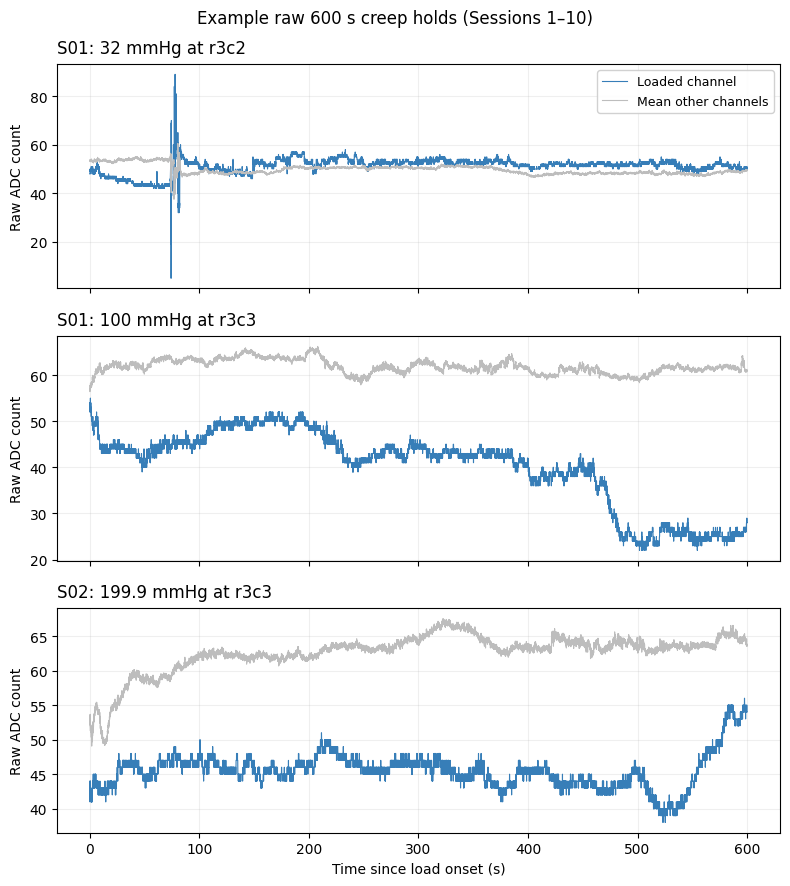

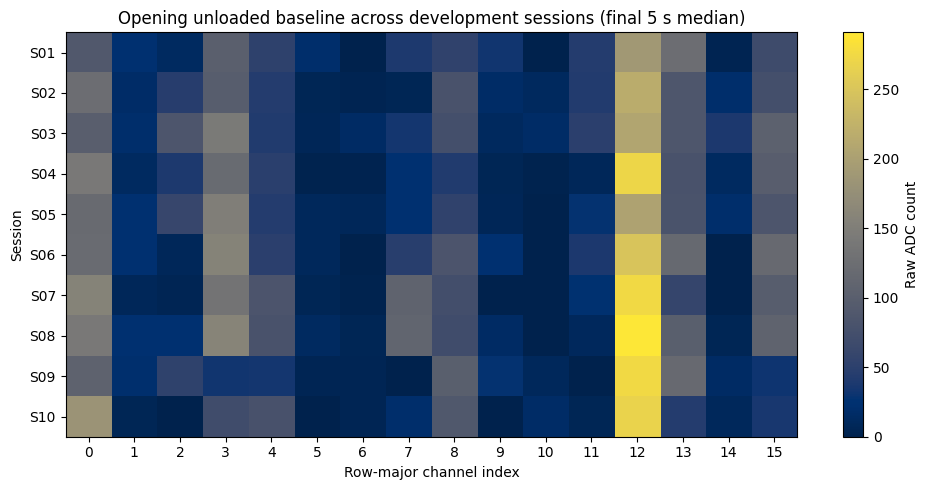

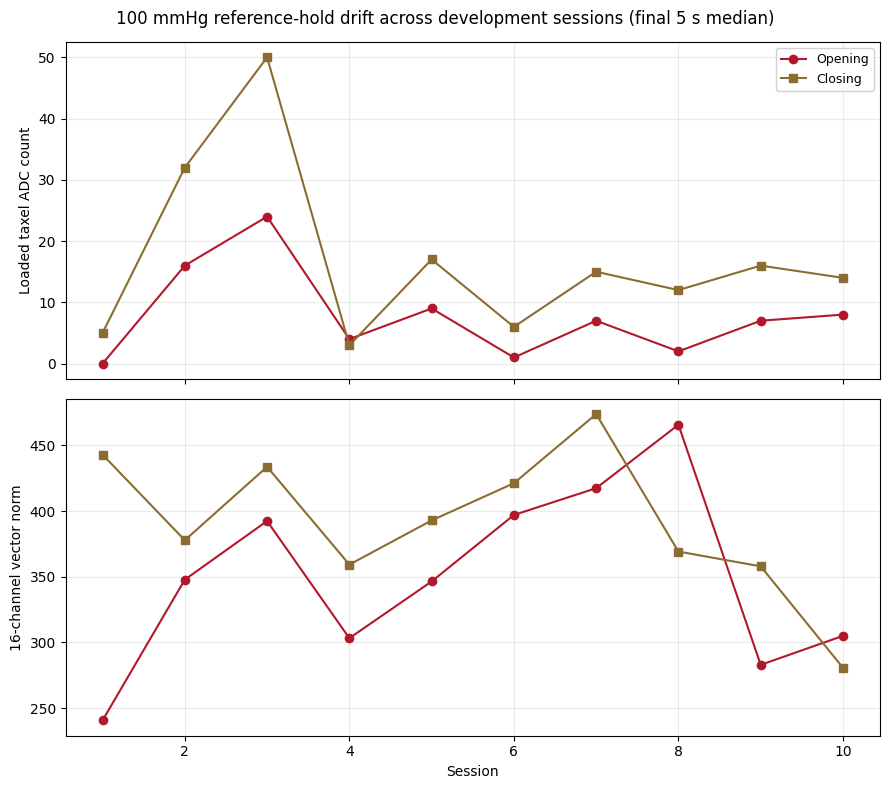

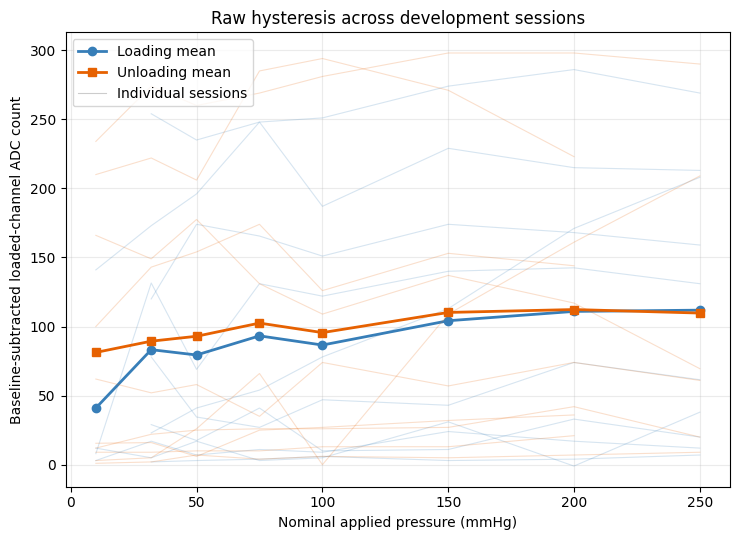

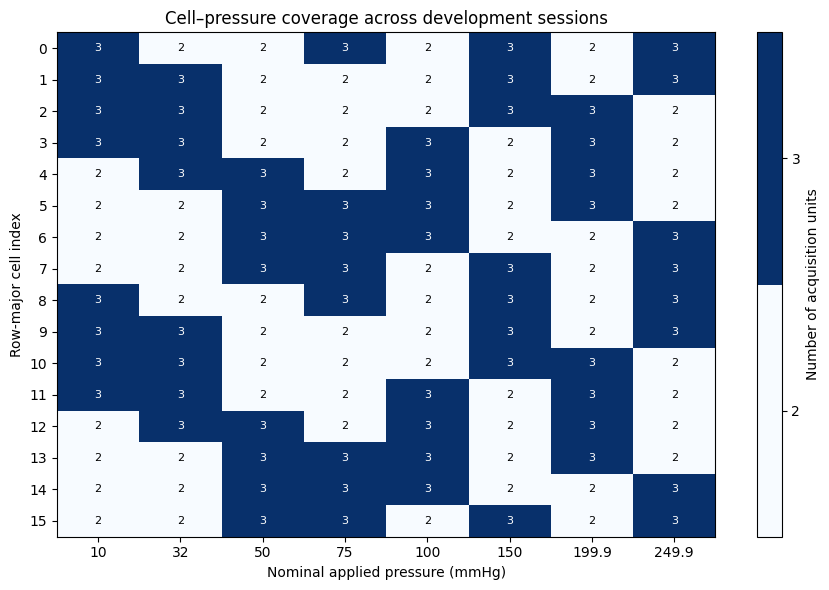

In [22]:
# Generate exploratory analyses from the development subset only
def make_eda(units):
    development = [unit for unit in units if unit.session_number <= 10]

    # Inspect representative raw creep responses at each nominal pressure level
    examples = []
    for pressure in [32.0, 100.0, 199.9]:
        unit = next(u for u in development if u.kind == "creep_hold" and np.isclose(u.pressure, pressure))
        positions = np.flatnonzero(unit.loaded)
        examples.append((unit, positions))
    fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
    loaded_colour = EDA_COLOURS["loading"]
    for axis, (unit, positions) in zip(axes, examples):
        time_axis = unit.elapsed[positions]
        axis.plot(time_axis, unit.x[positions, unit.cell], lw=0.8, color=loaded_colour, label="Loaded channel")
        axis.plot(time_axis, np.delete(unit.x[positions], unit.cell, axis=1).mean(axis=1), lw=0.8, color=EDA_COLOURS["other"], label="Mean other channels")
        r, c = divmod(unit.cell, 4)
        axis.set_title(f"S{unit.session_number:02d}: {unit.pressure:g} mmHg at r{r+1}c{c+1}", loc="left", pad=8)
        axis.set_ylabel("Raw ADC count"); axis.grid(alpha=0.2)
    axes[0].legend(loc="upper right", fontsize=9, frameon=True, framealpha=0.9, facecolor="white", edgecolor="0.8")
    axes[-1].set_xlabel("Time since load onset (s)")
    fig.suptitle("Example raw 600 s creep holds (Sessions 1–10)")
    fig.tight_layout()
    save_figure(fig, EDA_DIR, "representative_raw_creep_curves.png")

    # Examine session-to-session variation in the unloaded opening baseline
    opening = [unit for unit in development if unit.component == "opening_baseline"]
    baseline = np.stack([np.median(unit.x[-125:], axis=0) for unit in opening])
    fig, axis = plt.subplots(figsize=(10, 5))
    image = axis.imshow(baseline, aspect="auto", cmap="cividis")
    axis.set_xticks(range(16)); axis.set_yticks(range(10), [f"S{i:02d}" for i in range(1, 11)])
    axis.set_xlabel("Row-major channel index"); axis.set_ylabel("Session"); axis.set_title("Opening unloaded baseline across development sessions (final 5 s median)")
    fig.colorbar(image, ax=axis, label="Raw ADC count"); fig.tight_layout()
    save_figure(fig, EDA_DIR, "unloaded_baseline_heatmap.png")

    # Compare opening and closing reference holds to assess within-session drift
    references = [unit for unit in development if unit.kind == "reference_hold"]
    fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
    for component, marker, color in [("reference_opening", "o", EDA_COLOURS["opening"]), ("reference_closing", "s", EDA_COLOURS["closing"])]:
        selected = [unit for unit in references if unit.component == component]
        medians = np.stack([np.median(unit.x[np.flatnonzero(unit.loaded)[-125:]], axis=0) for unit in selected])
        loaded_taxel = np.array([
            median[unit.cell]
            for median, unit in zip(medians, selected)])
        axes[0].plot(range(1, 11), loaded_taxel, marker=marker, color=color, label=component.replace("reference_", "").capitalize())
        axes[1].plot(range(1, 11), np.linalg.norm(medians, axis=1), marker=marker, color=color, label=component.replace("reference_", "").capitalize())
    axes[0].set_ylabel("Loaded taxel ADC count"); axes[1].set_ylabel("16-channel vector norm"); axes[1].set_xlabel("Session")
    for axis in axes:
        axis.grid(alpha=0.25)
        axes[0].legend(loc="upper right", fontsize=9, frameon=True, framealpha=0.9, facecolor="white", edgecolor="0.8")
    fig.suptitle("100 mmHg reference-hold drift across development sessions (final 5 s median)", y=0.98)
    fig.tight_layout()
    save_figure(fig, EDA_DIR, "reference_hold_drift.png")

    # Compare loading and unloading responses to characterise raw hysteresis
    hysteresis = []
    for unit in development:
        if unit.kind != "hysteresis_step":
            continue
        loaded = np.flatnonzero(unit.loaded)
        unloaded = np.flatnonzero(~unit.loaded)
    # Estimate each response from the final 10 s of loading relative to the preceding 2 s baseline
        response = (np.median(unit.x[loaded[-250:], unit.cell]) - np.median(unit.x[unloaded[-50:], unit.cell]))
        hysteresis.append({"session": unit.session_number, "pressure": unit.pressure, "direction": hysteresis_direction(unit, units), "response": response,})
    hysteresis = pd.DataFrame(hysteresis)
    fig, axis = plt.subplots(figsize=(7.5, 5.5))
    for direction, marker, color in [("loading", "o", EDA_COLOURS["loading"]), ("unloading", "s", EDA_COLOURS["unloading"]),]:
        part = hysteresis[hysteresis.direction == direction]

    # Show individual session behaviour without allowing it to dominate the figure
        session_curves = (
            part.groupby(["session", "pressure"], as_index=False)
            .response.mean())
        for _, session_data in session_curves.groupby("session"):
            session_data = session_data.sort_values("pressure")
            axis.plot(session_data.pressure, session_data.response, color=color, lw=0.8, alpha=0.20,)
    # Overlay the development-set mean branch
        mean_curve = (
            part.groupby("pressure", as_index=False)
            .response.mean()
            .sort_values("pressure"))
        axis.plot(mean_curve.pressure, mean_curve.response, marker=marker, color=color, lw=2.0, label=f"{direction.capitalize()} mean",)
        # Add a single legend entry for the individual-session traces
    axis.plot([], [], color="0.5", lw=0.8, alpha=0.4, label="Individual sessions",)
    axis.set_xlabel("Nominal applied pressure (mmHg)")
    axis.set_ylabel("Baseline-subtracted loaded-channel ADC count")
    axis.set_title("Raw hysteresis across development sessions")
    axis.grid(alpha=0.25)
    axis.legend()
    fig.tight_layout()
    save_figure(fig, EDA_DIR, "raw_hysteresis.png")

    # Check cell-pressure coverage across the development data
    manifest = pd.read_csv(MANIFEST_PATH)
    coverage = manifest[(manifest.session_number <= 10) & (manifest.kind == "spatial_coverage_hold")].copy()
    coverage["cell"] = coverage.row_zero_based.astype(int) * 4 + coverage.col_zero_based.astype(int)
    pivot = coverage.groupby(["cell", "pressure_mmhg"]).size().unstack(fill_value=0).reindex(index=range(16))
    fig, axis = plt.subplots(figsize=(9, 6))
    coverage_cmap = plt.get_cmap("Blues", 2)
    image = axis.imshow(pivot, aspect="auto", cmap=coverage_cmap, vmin=1.5, vmax=3.5)
    axis.set_xticks(range(8), [f"{v:g}" for v in pivot.columns]); axis.set_yticks(range(16))
    axis.set_xlabel("Nominal applied pressure (mmHg)"); axis.set_ylabel("Row-major cell index"); axis.set_title("Cell–pressure coverage across development sessions")
    for r in range(16):
        for c in range(8):
            value = int(pivot.iloc[r, c])
            axis.text(c, r, value, ha="center", va="center", fontsize=8, color="white" if value == 3 else "black")
    cbar = fig.colorbar(image, ax=axis, ticks=[2, 3], boundaries=[1.5, 2.5, 3.5])
    cbar.set_label("Number of acquisition units")
    fig.tight_layout()
    save_figure(fig, EDA_DIR, "development_cell_pressure_coverage.png")
make_eda(units)

# **MODEL ARCHITECTURES AND BASELINES**

In [23]:
# Define a common calibration interface for the MLP, LSTM and GRU architectures
class NeuralCalibration(nn.Module):
    def __init__(self, model_type, input_size, hidden_size, output_mode):
        super().__init__()
        self.model_type = model_type
        self.output_mode = output_mode
        if model_type == "mlp":
            self.encoder = nn.Sequential(nn.Linear(input_size, hidden_size), nn.ReLU(), nn.Linear(hidden_size, hidden_size), nn.ReLU())
        elif model_type == "lstm":
            self.encoder = nn.LSTM(input_size, hidden_size, batch_first=True)
        elif model_type == "gru":
            self.encoder = nn.GRU(input_size, hidden_size, batch_first=True)
        else:
            raise ValueError(model_type)
        # Map the encoded representation to one pressure estimate per taxel
        self.output = nn.Linear(hidden_size, 16)
        # Initialise the output bias near zero pressure under the chosen output constraint
        nn.init.constant_(self.output.bias, -0.5 if output_mode == "softplus" else (0.01 if output_mode == "relu" else 0.0))

    def forward(self, x):
        # The MLP sees only the endpoint frame, whereas recurrent models receive the full sampled history
        if self.model_type == "mlp":
            hidden = self.encoder(x[:, -1])
        else:
            sequence, _ = self.encoder(x)
            hidden = sequence[:, -1]
        prediction = self.output(hidden)
        # Apply any in-model non-negativity constraint after the linear output layer
        if self.output_mode == "relu":
            return torch.relu(prediction)
        if self.output_mode == "softplus":
            return torch.nn.functional.softplus(prediction, beta=5.0)
        return prediction

In [24]:
# Apply post-hoc non-negativity only for the linear clip output variant
def constrained(prediction, output_mode):
    return np.maximum(prediction, 0.0) if output_mode == "linear_clip" else prediction

# **EVALUATION FRAMEWORK AND METRICS**

In [25]:
# Summarise pressure error, spatial localisation and false-positive response at acquisition-unit level
def metrics_from_predictions(units, records, y_true, y_pred):
    rows = []
    loaded_true = []
    loaded_pred = []
    for unit_index in np.unique(records[:, 0]):
        unit = units[int(unit_index)]
        positions = np.flatnonzero(records[:, 0] == unit_index)
        true = y_true[positions]
        pred = y_pred[positions]
        # Identify loaded endpoints from the non-zero ground-truth pressure maps
        loaded = true.max(axis=1) > 0
        row = {
            "unit_index": int(unit_index), "session": unit.session, "trial_index": unit.trial_index,
            "unit_id": unit.unit_id, "kind": unit.kind, "component": unit.component,
            "pressure_mmhg": unit.pressure, "cell": unit.cell,
            "overall_mae_mmhg": float(np.abs(pred - true).mean()),
            "unloaded_frame_false_positive_mmhg": float(pred[~loaded].mean()) if (~loaded).any() else np.nan,}
        # Separate pressure error at the labelled taxel from activation elsewhere on the array
        if loaded.any():
            local = pred[loaded, unit.cell]
            error = local - unit.pressure
            other = np.delete(pred[loaded], unit.cell, axis=1)
            row.update({
                "loaded_mae_mmhg": float(np.abs(error).mean()),
                "loaded_rmse_mmhg": float(np.sqrt(np.square(error).mean())),
                "signed_bias_mmhg": float(error.mean()),
                "unloaded_taxel_false_positive_mmhg": float(other.mean()),
                "spatial_accuracy": float((pred[loaded].argmax(axis=1) == unit.cell).mean()),
                "mean_loaded_prediction_mmhg": float(local.mean()), "loaded_endpoints": int(loaded.sum()),})
            loaded_true.append(unit.pressure)
            loaded_pred.append(float(local.mean()))
        else:
            for key in ["loaded_mae_mmhg", "loaded_rmse_mmhg", "signed_bias_mmhg", "unloaded_taxel_false_positive_mmhg", "spatial_accuracy", "mean_loaded_prediction_mmhg"]:
                row[key] = np.nan
            row["loaded_endpoints"] = 0
        rows.append(row)
    # Aggregate results by acquisition unit so that individual units contribute equally
    per_unit = pd.DataFrame(rows)
    loaded = per_unit[per_unit.loaded_endpoints > 0]
    true = np.asarray(loaded_true)
    pred = np.asarray(loaded_pred)
    # Compute the coefficient of determination (R²) from the mean loaded response of each acquisition unit
    denominator = np.square(true - true.mean()).sum()
    metrics = {
        "unit_loaded_mae_mmhg": float(loaded.loaded_mae_mmhg.mean()),
        "unit_loaded_mae_sd_mmhg": float(loaded.loaded_mae_mmhg.std(ddof=1)),
        "unit_loaded_rmse_mmhg": float(loaded.loaded_rmse_mmhg.mean()),
        "unit_loaded_r2": float(1 - np.square(pred - true).sum() / denominator),
        "unit_overall_mae_mmhg": float(per_unit.overall_mae_mmhg.mean()),
        "unit_signed_bias_mmhg": float(loaded.signed_bias_mmhg.mean()),
        "unit_unloaded_taxel_false_positive_mmhg": float(loaded.unloaded_taxel_false_positive_mmhg.mean()),
        "unit_unloaded_frame_false_positive_mmhg": float(per_unit.unloaded_frame_false_positive_mmhg.mean()),
        "unit_spatial_accuracy": float(loaded.spatial_accuracy.mean()),
        "loaded_units": int(len(loaded)), "all_units": int(len(per_unit)), "evaluation_endpoints": int(len(records)),}
    return metrics, per_unit

In [26]:
# Run neural model inference and return targets and predictions in mmHg
def predict_neural(model, loader, output_mode):
    model.eval()
    predictions, targets = [], []
    with torch.no_grad():
        for x, y in loader:
            # Restore physical pressure units before any post-hoc clipping
            prediction = model(x.to(DEVICE)).cpu().numpy() * TARGET_SCALE
            predictions.append(constrained(prediction, output_mode))
            targets.append(y.numpy() * TARGET_SCALE)
    return np.concatenate(targets), np.concatenate(predictions)

In [27]:
# Mean true/predicted 16-taxel vectors per unit, using loaded endpoints only where available
def unit_vectors(units, records, y_true, y_pred):
    rows = []
    for unit_index in np.unique(records[:, 0]):
        unit = units[int(unit_index)]
        positions = np.flatnonzero(records[:, 0] == unit_index)
        loaded = positions[y_true[positions].max(axis=1) > 0]
        selected = loaded if len(loaded) else positions
        true_vector = y_true[selected].mean(axis=0)
        pred_vector = y_pred[selected].mean(axis=0)
        row = {"unit_index": int(unit_index), "session": unit.session, "session_number": unit.session_number,
               "unit_id": unit.unit_id, "trial_index": unit.trial_index, "kind": unit.kind,
               "component": unit.component, "pressure_mmhg": unit.pressure, "cell": unit.cell}
        row.update({f"true_{i:02d}": true_vector[i] for i in range(16)})
        row.update({f"pred_{i:02d}": pred_vector[i] for i in range(16)})
        rows.append(row)
    return pd.DataFrame(rows)

# **MODEL TRAINING AND OPTIMISATION**

In [28]:
# Fit linear baselines using preprocessing estimated from the training partition only
def fit_linear(config, units, train_indices, validation_indices):
    preprocessor = fit_preprocessor(units, train_indices, config.preprocessing)
    train_records = training_records(units, train_indices)
    validation_records = evaluation_records(units, validation_indices)
    train_x = frame_matrix(units, train_records, preprocessor)
    train_y = targets_for_records(units, train_records)
    validation_x = frame_matrix(units, validation_records, preprocessor)
    validation_y = targets_for_records(units, validation_records)
    # Compare independent taxel-wise calibration with multichannel ridge regression
    if config.model == "per_taxel_linear":
        models = []
        prediction = np.empty_like(validation_y)
        for cell in range(16):
            model = LinearRegression().fit(train_x[:, [cell]], train_y[:, cell])
            prediction[:, cell] = model.predict(validation_x[:, [cell]])
            models.append(model)
    else:
        models = Ridge(alpha=config.alpha).fit(train_x, train_y)
        prediction = models.predict(validation_x)
    # Restrict linear baseline predictions to physically meaningful non-negative pressures
    prediction = np.maximum(prediction, 0.0)
    metrics, per_unit = metrics_from_predictions(units, validation_records, validation_y, prediction)
    return metrics, per_unit, {"model": models, "preprocessor": preprocessor, "records": validation_records, "y_true": validation_y, "y_pred": prediction}

In [29]:
# Train neural calibration models with reproducible sampling and validation-based model selection
def fit_neural(config, units, train_indices, validation_indices, fixed_epochs=None):
    set_seed(config.seed)
    preprocessor = fit_preprocessor(units, train_indices, config.preprocessing)
    train_records = training_records(units, train_indices)
    validation_records = evaluation_records(units, validation_indices)
    single_frame = config.model == "mlp"
    train_dataset = RecordDataset(units, train_records, preprocessor, config.context_seconds, config.derivatives, single_frame)
    validation_dataset = RecordDataset(units, validation_records, preprocessor, config.context_seconds, config.derivatives, single_frame)
    generator = torch.Generator().manual_seed(config.seed)
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, generator=generator, num_workers=0)
    validation_loader = DataLoader(validation_dataset, batch_size=config.batch_size * 2, shuffle=False, num_workers=0)
    model = NeuralCalibration(config.model, 32 if config.derivatives else 16, config.hidden_size, config.output).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
    best_state, best_score, best_epoch, stale = None, float("inf"), 0, 0
    history = []
    epochs = fixed_epochs if fixed_epochs is not None else config.max_epochs
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, total_count = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            prediction = model(x)
            # Upweight non-zero target taxels to reduce the influence of the sparse zero background
            weights = torch.where(y > 0, config.loaded_weight, 1.0)
            loss = (weights * (prediction - y).square()).sum(dim=1).mean()
            loss.backward()
            optimizer.step()
            total_loss += float(loss.detach()) * len(x)
            total_count += len(x)
        record = {"epoch": epoch, "train_loss": total_loss / total_count}
        # Evaluate validation performance when epoch selection is enabled
        if fixed_epochs is None:
            true, pred = predict_neural(model, validation_loader, config.output)
            validation_metrics, _ = metrics_from_predictions(units, validation_records, true, pred)
            record.update(validation_metrics)
            score = validation_metrics["unit_loaded_mae_mmhg"]
            # Require a minimum reduction in validation error before accepting a new best epoch
            if score < best_score - 1e-5:
                best_score = score
                best_epoch = epoch
                best_state = copy.deepcopy(model.state_dict())
                stale = 0
            else:
                stale += 1
                if stale >= config.patience:
                    history.append(record)
                    break
        history.append(record)
    # Restore the best validation checkpoint with fixed-epoch refits retaining the final trained state
    if fixed_epochs is None:
        model.load_state_dict(best_state)
    else:
        best_epoch = fixed_epochs
    true, pred = predict_neural(model, validation_loader, config.output)
    metrics, per_unit = metrics_from_predictions(units, validation_records, true, pred)
    metrics.update({"best_epoch": int(best_epoch), "parameter_count": int(sum(p.numel() for p in model.parameters()))})
    return metrics, per_unit, {"model": model, "preprocessor": preprocessor, "history": pd.DataFrame(history), "records": validation_records, "y_true": true, "y_pred": pred}

# **CHRONOLOGICAL FORWARD VALIDATION AND MODEL SELECTION**

In [30]:
# Evaluate each configuration using expanding-window forward validation across the development sessions
def run_forward_validation(config, units):
    rows = []
    for train_sessions, validation_session in FOLDS:
        train_indices = subset_indices(units, train_sessions)
        validation_indices = subset_indices(units, [validation_session],)
        started = time.perf_counter()
        if config.model in {"ridge", "per_taxel_linear"}:
            metrics, _, _ = fit_linear(config, units, train_indices, validation_indices,)
        else:
            metrics, _, _ = fit_neural(config, units, train_indices, validation_indices,)
        rows.append({"experiment": config.name, "train_sessions": f"1-{train_sessions[-1]}", "validation_session": validation_session, "runtime_seconds": time.perf_counter() - started, **metrics,})
    return pd.DataFrame(rows)

In [31]:
def make_selection_outputs(selection_results):
    # Compare deterministic baselines with neural models evaluated across three random seeds
    comparisons = {
        "Per-taxel linear": ["per_taxel_linear_global",],
        "Ridge": ["ridge_global",],
        "MLP": ["mlp_global_softplus", "mlp_global_softplus_seed2027", "mlp_global_softplus_seed2028",],
        "LSTM": ["lstm_global_context_30s", "lstm_global_30s_seed2027", "lstm_global_30s_seed2028",],
        "GRU": ["gru_global", "gru_global_seed2027", "gru_global_seed2028",],}
    rows = []
    fig, axis = plt.subplots(figsize=(10, 5))
    for label, names in comparisons.items():
        frames = [selection_results[name] for name in names]
        combined = pd.concat(
            [
                frame.assign(seed_run=i)
                for i, frame in enumerate(frames)],
            ignore_index=True,)
        # Average repeated neural runs within each forward-validation fold
        fold_curve = (
            combined
            .groupby("validation_session")
            .unit_loaded_mae_mmhg
            .mean())
        # Mean validation performance from each independent seed
        run_means = np.array([
            frame.unit_loaded_mae_mmhg.mean()
            for frame in frames])
        axis.plot(fold_curve.index, fold_curve.values, marker="o", label=label, color=MODEL_COLOURS[label],)
        rows.append({
            "Model": label,
            "Mean validation MAE (mmHg)": run_means.mean(),
            "SD across folds (mmHg)": fold_curve.std(ddof=1),
            "SD across seeds (mmHg)": (
                run_means.std(ddof=1)
                if len(run_means) > 1
                else np.nan),
            "Seed runs": len(names),})

    axis.set_xticks(range(6, 11))
    axis.set_xlabel("Forward validation session")
    axis.set_ylabel("Unit-level loaded-taxel MAE (mmHg)")
    axis.set_title("Expanding-window chronological forward validation")
    axis.grid(alpha=0.25)
    axis.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=1, frameon=False, fontsize=9,)
    fig.tight_layout(rect=[0, 0, 0.78, 1])
    save_figure(fig, FIGURES_DIR, "forward_validation_models.png",)
    model_table = pd.DataFrame(rows)
    show_table(model_table)
    model_table.to_csv(TABLES_DIR / "forward_validation_summary.csv", index=False,)

    # One-factor-at-a-time LSTM hyperparameter comparisons
    groups = {
        "Preprocessing": [
            ("Global", "lstm_preprocess_global"),
            ("Session opening baseline", "lstm_preprocess_opening"),
            ("Unit pre-load baseline", "lstm_preprocess_unit"),],
        "Context": [
            ("1 s", "lstm_preprocess_global"),
            ("5 s", "lstm_global_context_5s"),
            ("30 s", "lstm_global_context_30s"),
            ("60 s", "lstm_global_context_60s"),
            ("300 s", "lstm_global_context_300s"),],
        "Loaded weight": [
            ("1", "lstm_global_weight_1"),
            ("5", "lstm_global_weight_5"),
            ("15", "lstm_global_context_30s"),
            ("30", "lstm_global_weight_30"),],
        "Hidden size": [
            ("16", "lstm_global_hidden_16"),
            ("32", "lstm_global_context_30s"),
            ("64", "lstm_global_hidden_64"),],
        "Output": [
            ("Linear + clip", "lstm_global_context_30s"),
            ("ReLU", "lstm_global_relu"),
            ("Softplus", "lstm_global_softplus"),],}
    # Select the candidate with the lowest mean forward-validation MAE
    retained = {
        group: min(
            candidates,
            key=lambda item: (
                selection_results[item[1]]
                .unit_loaded_mae_mmhg
                .mean()),)[0]
        for group, candidates in groups.items()}
    rows = []
    for group, candidates in groups.items():
        for label, name in candidates:
            values = selection_results[name].unit_loaded_mae_mmhg
            rows.append({
                "Parameter": group,
                "Candidate": label,
                "Mean MAE (mmHg)": values.mean(),
                "SD (mmHg)": values.std(ddof=1),
                "Selected": label == retained[group],})

    selection_table = pd.DataFrame(rows)
    show_table(selection_table)
    selection_table.to_csv(TABLES_DIR / "hyperparameter_selection.csv", index=False,)
    return model_table, selection_table

In [32]:
# Configurations required for model selection
configs = [
    # Baselines and headline model comparison
    ExperimentConfig("per_taxel_linear_global", model="per_taxel_linear",),
    ExperimentConfig("ridge_global", model="ridge",),
    ExperimentConfig("mlp_global_softplus", model="mlp", output="softplus",),
    ExperimentConfig("gru_global", model="gru", context_seconds=30,),
    # Additional MLP seeds for optimisation variability
    ExperimentConfig("mlp_global_softplus_seed2027", model="mlp", output="softplus", seed=2027,),
    ExperimentConfig("mlp_global_softplus_seed2028", model="mlp", output="softplus", seed=2028,),
    # Additional GRU seeds for optimisation variability
    ExperimentConfig("gru_global_seed2027", model="gru", context_seconds=30, seed=2027,),
    ExperimentConfig("gru_global_seed2028", model="gru", context_seconds=30, seed=2028,),
    # Preprocessing comparison
    ExperimentConfig("lstm_preprocess_opening", model="lstm", preprocessing="session_opening", context_seconds=1,),
    ExperimentConfig("lstm_preprocess_global", model="lstm", context_seconds=1,),
    ExperimentConfig("lstm_preprocess_unit", model="lstm", preprocessing="unit_prelude", context_seconds=1,),
    # Temporal context
    ExperimentConfig("lstm_global_context_5s", model="lstm", context_seconds=5,),
    ExperimentConfig("lstm_global_context_30s", model="lstm", context_seconds=30,),
    ExperimentConfig("lstm_global_context_60s", model="lstm", context_seconds=60,),
    ExperimentConfig("lstm_global_context_300s", model="lstm", context_seconds=300,),
    # Loaded-taxel weighting
    ExperimentConfig("lstm_global_weight_1", model="lstm", context_seconds=30, loaded_weight=1,),
    ExperimentConfig("lstm_global_weight_5", model="lstm", context_seconds=30, loaded_weight=5,),
    ExperimentConfig("lstm_global_weight_30", model="lstm", context_seconds=30, loaded_weight=30,),
    # Hidden size
    ExperimentConfig("lstm_global_hidden_16", model="lstm", context_seconds=30, hidden_size=16,),
    ExperimentConfig("lstm_global_hidden_64", model="lstm", context_seconds=30, hidden_size=64,),
    # Output constraint
    ExperimentConfig("lstm_global_relu", model="lstm", context_seconds=30, output="relu",),
    ExperimentConfig("lstm_global_softplus", model="lstm", context_seconds=30, output="softplus",),
    # Additional LSTM seeds for optimisation variability and final epoch selection
    ExperimentConfig("lstm_global_30s_seed2027", model="lstm", context_seconds=30, seed=2027,),
    ExperimentConfig("lstm_global_30s_seed2028", model="lstm", context_seconds=30, seed=2028,),
]

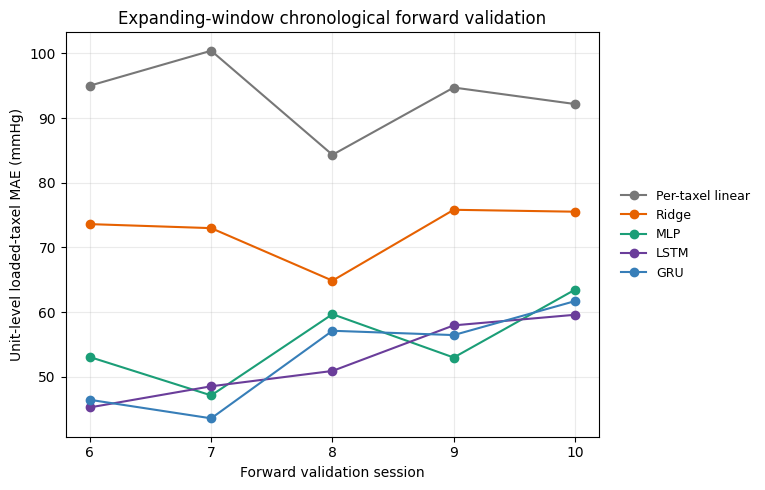

Model,Mean validation MAE (mmHg),SD across folds (mmHg),SD across seeds (mmHg),Seed runs
Per-taxel linear,93.338,5.867,—,1
Ridge,72.558,4.473,—,1
MLP,55.248,6.392,1.613,3
LSTM,52.435,6.138,1.745,3
GRU,53.044,7.691,0.753,3


Parameter,Candidate,Mean MAE (mmHg),SD (mmHg),Selected
Preprocessing,Global,51.134,6.766,True
Preprocessing,Session opening baseline,59.097,6.329,False
Preprocessing,Unit pre-load baseline,56.796,4.436,False
Context,1 s,51.134,6.766,False
Context,5 s,50.994,6.484,False
Context,30 s,50.421,6.396,True
Context,60 s,50.638,7.467,False
Context,300 s,50.441,7.742,False
Loaded weight,1,53.158,5.754,False
Loaded weight,5,52.352,7.575,False


LSTM final training epochs: 6
MLP final training epochs: 7
GRU final training epochs: 7


In [33]:
selection_results = {
    config.name: run_forward_validation(config, units)
    for config in configs}
validation_table, selection_table = make_selection_outputs(selection_results)

# Derive each neural model's final training duration from the median best epoch across seeds and forward-validation folds
def median_best_epoch(names):
    epochs = []
    for name in names:
        epochs.extend(
            selection_results[name]
            .best_epoch
            .astype(int)
            .tolist())
    return int(np.median(epochs))

lstm_final_epochs = median_best_epoch([ "lstm_global_context_30s", "lstm_global_30s_seed2027", "lstm_global_30s_seed2028",])
mlp_final_epochs = median_best_epoch(["mlp_global_softplus", "mlp_global_softplus_seed2027", "mlp_global_softplus_seed2028",])
gru_final_epochs = median_best_epoch(["gru_global", "gru_global_seed2027", "gru_global_seed2028",])
print(f"LSTM final training epochs: {lstm_final_epochs}")
print(f"MLP final training epochs: {mlp_final_epochs}")
print(f"GRU final training epochs: {gru_final_epochs}")

# **FINAL HELD-OUT EVALUATION**

In [34]:
# Isolate each held-out session before applying the common unit-level evaluation
def metrics_for_session(units, records, y_true, y_pred, number):
    mask = np.asarray([units[int(index)].session_number == number for index in records[:, 0]])
    return metrics_from_predictions(units, records[mask], y_true[mask], y_pred[mask])

In [35]:
# Refit the selected neural family and evaluate it on the fixed held-out data across multiple seeds
def run_final_family(units, train_indices, test_indices, family, model_type, output_mode, context_seconds, fixed_epochs):
    metric_rows, predictions, models, preprocessors = [], [], [], []
    records = y_true = None
    # Repeat the final fit across seeds to quantify optimisation variability
    for seed in FINAL_SEEDS:
        # Keep the model selection choices fixed during test evaluation
        config = ExperimentConfig(
            name=f"{family}_seed_{seed}", model=model_type, preprocessing="global", context_seconds=context_seconds,
            hidden_size=32, learning_rate=1e-3, loaded_weight=15.0, output=output_mode, seed=seed,)
        started = time.perf_counter()
        # Train for the previously selected epoch count without further test model selection
        metrics, _, artefacts = fit_neural(config, units, train_indices, test_indices, fixed_epochs=fixed_epochs)
        records, y_true, y_pred = artefacts["records"], artefacts["y_true"], artefacts["y_pred"]
        metric_rows.append({"model": family, "seed": seed, "session": "pooled_unit_balanced", "runtime_seconds": time.perf_counter() - started, **metrics})
        # Report the two test sessions separately to expose session-to-session variation
        for number in [11, 12]:
            session_metrics, _ = metrics_for_session(units, records, y_true, y_pred, number)
            metric_rows.append({"model": family, "seed": seed, "session": session_id(number), **session_metrics})
        predictions.append(y_pred)
        models.append(artefacts["model"])
        preprocessors.append(artefacts["preprocessor"])
    metrics_frame = pd.DataFrame(metric_rows)
    pooled = metrics_frame[metrics_frame.session == "pooled_unit_balanced"]
    summary = {"model": family, "seeds": len(FINAL_SEEDS),}
    for column in pooled.select_dtypes(include=np.number).columns:
        if column != "seed":
            summary[f"{column}_mean"] = float(pooled[column].mean())
            summary[f"{column}_sd"] = float(pooled[column].std(ddof=1))
    return {"summary": summary, "metrics": metrics_frame, "records": records, "y_true": y_true, "predictions": np.stack(predictions), "models": models, "preprocessors": preprocessors, "model_type": model_type, "output_mode": output_mode, "context_seconds": context_seconds,}

In [36]:
# Evaluate the linear baselines on the same split for direct comparison
def run_final_linear(units, train_indices, test_indices, name, model_type):
    config = ExperimentConfig(name=name, model=model_type, preprocessing="global")
    metrics, _, _ = fit_linear(config, units, train_indices, test_indices)
    return {"model": name, **metrics,}

In [37]:
# Generate session predictions for post-hoc analysis without refitting the models
def predict_all_sessions(units, family_result):
    records = evaluation_records(units, subset_indices(units, range(1, 13)))
    predictions = []
    y_true = None
    for model, preprocessor in zip(family_result["models"], family_result["preprocessors"]):
        dataset = RecordDataset(units, records, preprocessor, family_result["context_seconds"], False, family_result["model_type"] == "mlp")
        loader = DataLoader(dataset, batch_size=512, shuffle=False, num_workers=0)
        true, prediction = predict_neural(model, loader, family_result["output_mode"])
        y_true = true if y_true is None else y_true
        predictions.append(prediction)
    return records, y_true, np.stack(predictions)

In [38]:
# Benchmark single-sample CPU forward-pass latency against the 25 Hz acquisition rate
def deployment_benchmark(model):
    model = copy.deepcopy(model).cpu().eval()
    example = torch.zeros((1, 64, 16))
    with torch.no_grad():
        for _ in range(100):
            model(example)
        started = time.perf_counter()
        for _ in range(2000):
            model(example)
        latency_ms = (time.perf_counter() - started) / 2000 * 1000
    result = pd.DataFrame([{
        "Device": "CPU",
        "Model forward-pass latency (ms)": latency_ms,
        "Model throughput (Hz)": 1000 / latency_ms,
        "Acquisition target (Hz)": 25.0,
        "Throughput / 25 Hz target": (1000 / latency_ms) / 25.0,
        "Parameters": sum(p.numel() for p in model.parameters()),}])
    display(result.round(3))
    result.to_csv(TABLES_DIR / "deployment_benchmark.csv", index=False,)
    return result

In [39]:
# Fit on Sessions 1–10 and reserve Sessions 11–12 for final held-out evaluation
train_indices = subset_indices(units, range(1, 11))
test_indices = subset_indices(units, [11, 12])

lstm_result = run_final_family(units, train_indices, test_indices, "lstm", "lstm", "linear_clip", 30, lstm_final_epochs,)
mlp_result = run_final_family(units, train_indices, test_indices, "mlp", "mlp", "softplus", 1, mlp_final_epochs,)
gru_result = run_final_family(units, train_indices, test_indices, "gru", "gru", "linear_clip", 30, gru_final_epochs,)

baselines = [
    run_final_linear(units, train_indices, test_indices, "per_taxel_linear", "per_taxel_linear",),
    run_final_linear(units, train_indices, test_indices, "ridge", "ridge",),]

deployment_result = deployment_benchmark(lstm_result["models"][0])

,Device,Model forward-pass latency (ms),Model throughput (Hz),Acquisition target (Hz),Throughput / 25 Hz target,Parameters
0,CPU,0.492,2033.94,25.0,81.358,6928


In [40]:
# Assemble the headline test metrics across baselines and neural models
final_table = pd.DataFrame([
    {
        "Model": "Per-taxel linear",
        "MAE mean (mmHg)": baselines[0]["unit_loaded_mae_mmhg"],
        "SD across seeds (mmHg)": np.nan,
        "Seed runs": 1,
        "RMSE (mmHg)": baselines[0]["unit_loaded_rmse_mmhg"],
        "R²": baselines[0]["unit_loaded_r2"],
        "Spatial accuracy": baselines[0]["unit_spatial_accuracy"],},
    {
        "Model": "Ridge",
        "MAE mean (mmHg)": baselines[1]["unit_loaded_mae_mmhg"],
        "SD across seeds (mmHg)": np.nan,
        "Seed runs": 1,
        "RMSE (mmHg)": baselines[1]["unit_loaded_rmse_mmhg"],
        "R²": baselines[1]["unit_loaded_r2"],
        "Spatial accuracy": baselines[1]["unit_spatial_accuracy"],},
    {
        "Model": "MLP",
        "MAE mean (mmHg)": mlp_result["summary"]["unit_loaded_mae_mmhg_mean"],
        "SD across seeds (mmHg)": mlp_result["summary"]["unit_loaded_mae_mmhg_sd"],
        "Seed runs": len(FINAL_SEEDS),
        "RMSE (mmHg)": mlp_result["summary"]["unit_loaded_rmse_mmhg_mean"],
        "R²": mlp_result["summary"]["unit_loaded_r2_mean"],
        "Spatial accuracy": mlp_result["summary"]["unit_spatial_accuracy_mean"],},
    {
        "Model": "LSTM",
        "MAE mean (mmHg)": lstm_result["summary"]["unit_loaded_mae_mmhg_mean"],
        "SD across seeds (mmHg)": lstm_result["summary"]["unit_loaded_mae_mmhg_sd"],
        "Seed runs": len(FINAL_SEEDS),
        "RMSE (mmHg)": lstm_result["summary"]["unit_loaded_rmse_mmhg_mean"],
        "R²": lstm_result["summary"]["unit_loaded_r2_mean"],
        "Spatial accuracy": lstm_result["summary"]["unit_spatial_accuracy_mean"],},
    {
        "Model": "GRU",
        "MAE mean (mmHg)": gru_result["summary"]["unit_loaded_mae_mmhg_mean"],
        "SD across seeds (mmHg)": gru_result["summary"]["unit_loaded_mae_mmhg_sd"],
        "Seed runs": len(FINAL_SEEDS),
        "RMSE (mmHg)": gru_result["summary"]["unit_loaded_rmse_mmhg_mean"],
        "R²": gru_result["summary"]["unit_loaded_r2_mean"],
        "Spatial accuracy": gru_result["summary"]["unit_spatial_accuracy_mean"],},])

show_table(final_table)
final_table.to_csv(TABLES_DIR / "final_heldout_metrics.csv", index=False,)

Model,MAE mean (mmHg),SD across seeds (mmHg),Seed runs,RMSE (mmHg),R²,Spatial accuracy
Per-taxel linear,87.090,—,1,87.150,-1.189,0.373
Ridge,68.959,—,1,69.080,-0.431,0.656
MLP,44.211,2.244,5,45.464,0.383,0.714
LSTM,44.893,4.656,5,45.980,0.369,0.695
GRU,40.781,1.929,5,41.656,0.491,0.639


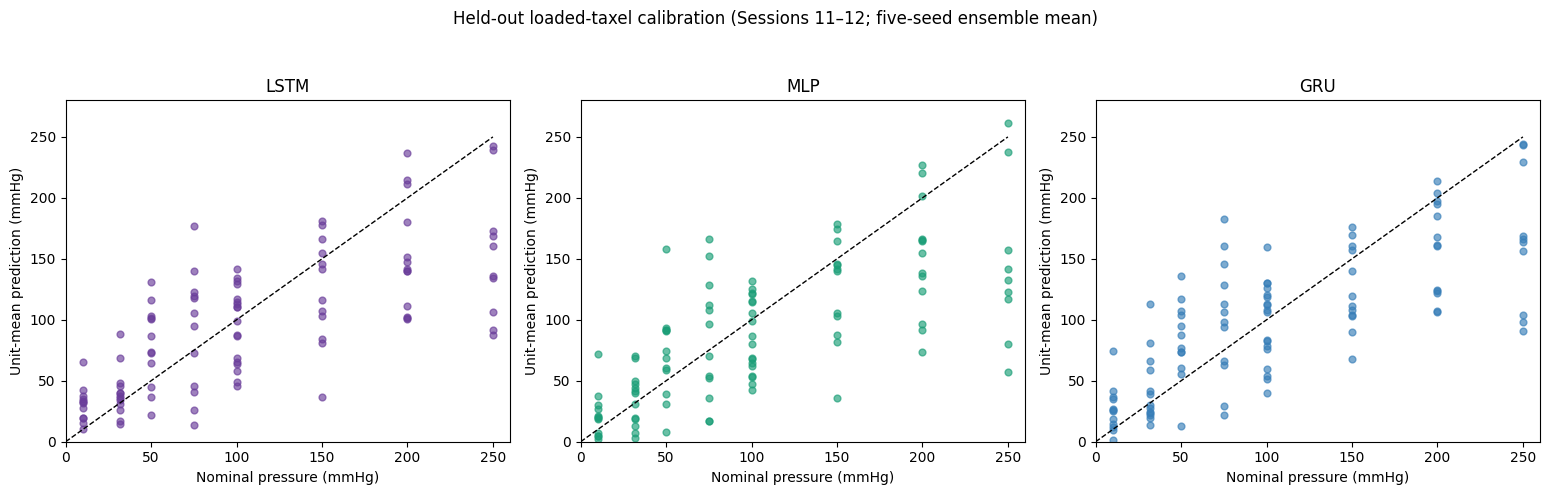

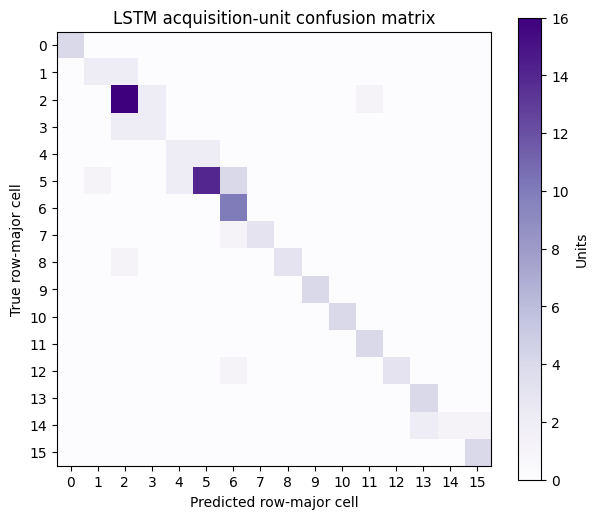

In [41]:
# Compare held-out pressure calibration and spatial localisation at acquisition unit level
def scatter_confusion(units, family_results):
    fig, axes = plt.subplots(
    1, len(family_results),
    figsize=(5.2 * len(family_results), 5),
    squeeze=False,)
    axes = axes.ravel()
    rows = []
    lstm_matrix = None
    for axis, (label, result) in zip(axes, family_results.items()):
        ensemble = result["predictions"].mean(axis=0)
        vectors = unit_vectors(units, result["records"], result["y_true"], ensemble)
        loaded = vectors[vectors.cell >= 0]
        true = loaded.pressure_mmhg.to_numpy()
        pred = np.asarray([
            row[f"pred_{int(row.cell):02d}"]
            for _, row in loaded.iterrows()])
        axis.scatter(true, pred, alpha=0.65, s=24, color=MODEL_COLOURS[label])
        axis.plot([0, 250], [0, 250], "k--", lw=1)
        axis.set_xlim(0, 260)
        axis.set_ylim(0, 280)
        axis.set_xlabel("Nominal pressure (mmHg)")
        axis.set_ylabel("Unit-mean prediction (mmHg)")
        axis.set_title(label)
        predicted_cell = loaded[
            [f"pred_{i:02d}" for i in range(16)]
        ].to_numpy().argmax(axis=1)
        matrix = confusion_matrix(loaded.cell.astype(int), predicted_cell, labels=range(16))
        for true_cell in range(16):
            for predicted in range(16):
                rows.append({
                    "model": label,
                    "true_cell": true_cell,
                    "predicted_cell": predicted,
                    "unit_count": int(matrix[true_cell, predicted])})
        if label == "LSTM":
            lstm_matrix = matrix.copy()
    fig.suptitle("Held-out loaded-taxel calibration (Sessions 11–12; five-seed ensemble mean)")
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    save_figure(fig, FIGURES_DIR, "heldout_loaded_scatter.png")

    # Plot the LSTM spatial confusion matrix separately
    fig2, axis2 = plt.subplots(figsize=(7, 6))
    image = axis2.imshow(lstm_matrix, cmap="Purples")
    axis2.set_xlabel("Predicted row-major cell")
    axis2.set_ylabel("True row-major cell")
    axis2.set_title("LSTM acquisition-unit confusion matrix")
    axis2.set_xticks(range(16))
    axis2.set_yticks(range(16))
    fig2.colorbar(image, ax=axis2, label="Units")
    save_figure(fig2, FIGURES_DIR, "lstm_spatial_confusion_matrix.png")
    confusion_table = pd.DataFrame(rows)
    confusion_table.to_csv(TABLES_DIR / "spatial_confusion_counts.csv", index=False,)
    return confusion_table

family_results = {"LSTM": lstm_result, "MLP": mlp_result, "GRU": gru_result}
spatial_confusion_table = scatter_confusion(units, family_results,)

In [42]:
# Summarise held-out performance separately for Sessions 11 and 12
def heldout_session_summary(family_results):
    rows = []
    for label in ["LSTM", "MLP", "GRU"]:
        result = family_results[label]
        part = result["metrics"][
            result["metrics"]["session"].isin(["SESSION11", "SESSION12"])]
        for session, group in part.groupby("session"):
            rows.append({
                "Model": label,
                "Session": session,
                "MAE mean (mmHg)":
                    group["unit_loaded_mae_mmhg"].mean(),
                "MAE SD across seeds (mmHg)":
                    group["unit_loaded_mae_mmhg"].std(ddof=1),
                "RMSE mean (mmHg)":
                    group["unit_loaded_rmse_mmhg"].mean(),
                "R² mean":
                    group["unit_loaded_r2"].mean(),
                "Spatial accuracy mean":
                    group["unit_spatial_accuracy"].mean(),})
    table = pd.DataFrame(rows)
    display(table.round(3))
    table.to_csv(TABLES_DIR / "heldout_metrics_by_session.csv", index=False,)
    return table

heldout_session_table = heldout_session_summary(family_results)

,Model,Session,MAE mean (mmHg),MAE SD across seeds (mmHg),RMSE mean (mmHg),R² mean,Spatial accuracy mean
0,LSTM,SESSION11,45.067,5.314,45.903,0.357,0.697
1,LSTM,SESSION12,44.720,5.523,46.058,0.381,0.693
2,MLP,SESSION11,45.755,3.969,46.874,0.310,0.703
3,MLP,SESSION12,42.668,1.484,44.055,0.456,0.725
4,GRU,SESSION11,38.843,2.838,39.560,0.502,0.622
5,GRU,SESSION12,42.719,1.801,43.753,0.478,0.656


In [43]:
# Compare test calibration error across acquisition types
def heldout_error_by_kind(units, family_results):
    rows = []
    for label, result in family_results.items():
        records = result["records"]
        y_true = result["y_true"]
        for seed_index, seed in enumerate(FINAL_SEEDS):
            prediction = result["predictions"][seed_index]
            for unit_index in np.unique(records[:, 0]):
                unit = units[int(unit_index)]
                positions = np.flatnonzero(
                    (records[:, 0] == unit_index) & (y_true.max(axis=1) > 0))
                if not len(positions):
                    continue
                error = prediction[positions, unit.cell] - unit.pressure
                rows.append({
                    "Model": label,
                    "Seed": seed,
                    "Session": unit.session,
                    "Unit ID": unit.unit_id,
                    "Acquisition type": unit.kind,
                    "Unit MAE (mmHg)": float(np.abs(error).mean()),})
    frame = pd.DataFrame(rows)
    per_seed = (
        frame
        .groupby(
            ["Model", "Seed", "Acquisition type"],
            as_index=False,)["Unit MAE (mmHg)"]
        .mean())
    summary = (
        per_seed
        .groupby(["Model", "Acquisition type"])["Unit MAE (mmHg)"]
        .agg(["mean", "std"])
        .reset_index()
        .rename(columns={
            "mean": "Mean MAE (mmHg)",
            "std": "SD across seeds (mmHg)",}))
    unit_counts = (
        frame[
            ["Model", "Acquisition type", "Session", "Unit ID"]]
        .drop_duplicates()
        .groupby(["Model", "Acquisition type"])
        .size()
        .rename("Units")
        .reset_index())
    summary = summary.merge(
        unit_counts,
        on=["Model", "Acquisition type"],)
    summary["Acquisition type"] = summary["Acquisition type"].replace({
        "creep_hold": "Creep hold",
        "hysteresis_step": "Hysteresis step",
        "reference_hold": "Reference hold",
        "spatial_coverage_hold": "Spatial coverage hold",})
    display(summary.round(3))
    summary.to_csv(TABLES_DIR / "heldout_error_by_acquisition_type.csv", index=False,)
    return summary

heldout_kind_table = heldout_error_by_kind(units, family_results,)

,Model,Acquisition type,Mean MAE (mmHg),SD across seeds (mmHg),Units
0,GRU,Creep hold,50.282,7.254,4
1,GRU,Hysteresis step,28.414,3.078,30
2,GRU,Reference hold,15.989,2.575,4
3,GRU,Spatial coverage hold,47.534,3.094,64
4,LSTM,Creep hold,50.238,7.917,4
5,LSTM,Hysteresis step,34.572,6.481,30
6,LSTM,Reference hold,23.990,8.232,4
7,LSTM,Spatial coverage hold,50.704,4.158,64
8,MLP,Creep hold,55.882,9.583,4
9,MLP,Hysteresis step,33.174,5.330,30


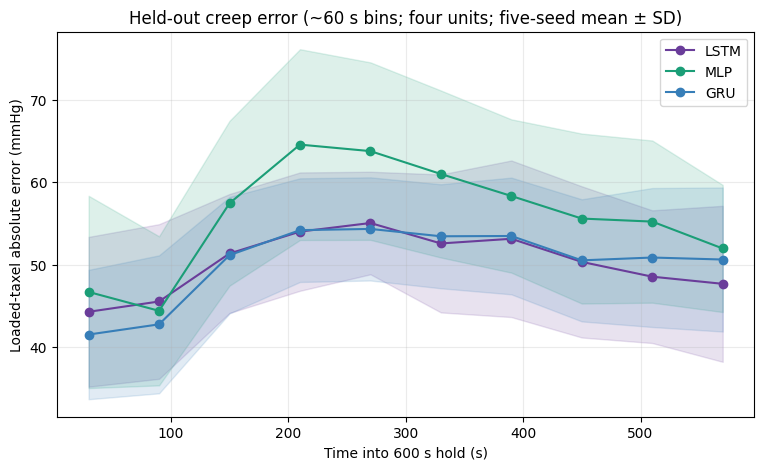

In [44]:
# Track calibration error through the 600 s test creep holds
def creep_analysis(units, family_results):
    rows = []
    bins = np.r_[np.arange(0, 600, 60), 601]
    for label, result in family_results.items():
        records = result["records"]
        y_true = result["y_true"]
        for seed_index, seed in enumerate(FINAL_SEEDS):
            prediction = result["predictions"][seed_index]
            for unit_index in np.unique(records[:, 0]):
                unit = units[int(unit_index)]
                if unit.kind != "creep_hold":
                    continue
                positions = np.flatnonzero(
                    (records[:, 0] == unit_index) & (y_true.max(axis=1) > 0))
                elapsed = unit.elapsed[
                    records[positions, 1]]
                error = np.abs(
                    prediction[positions, unit.cell] - unit.pressure)
                for lower, upper in zip(
                    bins[:-1],
                    bins[1:],):
                    mask = (
                        (elapsed >= lower) & (elapsed < upper))
                    if mask.any():
                        rows.append({
                            "model": label,
                            "seed": seed,
                            "session": unit.session,
                            "unit_id": unit.unit_id,
                            "pressure_mmhg": unit.pressure,
                            "time_bin_start_s": lower,
                            "absolute_error_mmhg":
                                float(error[mask].mean()),})
    frame = pd.DataFrame(rows)
    per_seed = (
        frame
        .groupby(
            ["model", "seed", "time_bin_start_s"])
        .absolute_error_mmhg
        .mean()
        .reset_index())
    summary = (
        per_seed
        .groupby(
            ["model", "time_bin_start_s"])
        .absolute_error_mmhg
        .agg(["mean", "std"])
        .reset_index())
    summary.to_csv(TABLES_DIR / "creep_error_vs_time.csv", index=False,)
    fig, axis = plt.subplots(figsize=(9, 5))
    for label in ["LSTM", "MLP", "GRU"]:
        part = summary[summary.model == label]
        centers = np.minimum(part.time_bin_start_s + 30, 570,)
        axis.plot(centers, part["mean"], marker="o", color=MODEL_COLOURS[label], label=label,)
        axis.fill_between(centers, part["mean"] - part["std"], part["mean"] + part["std"], color=MODEL_COLOURS[label], alpha=0.15,)
    axis.set_xlabel("Time into 600 s hold (s)")
    axis.set_ylabel("Loaded-taxel absolute error (mmHg)")
    axis.set_title("Held-out creep error (~60 s bins; four units; five-seed mean ± SD)")
    axis.grid(alpha=0.25)
    axis.legend()
    save_figure(fig, FIGURES_DIR, "creep_error_vs_time.png",)
    return summary

creep_table = creep_analysis(units, family_results,)

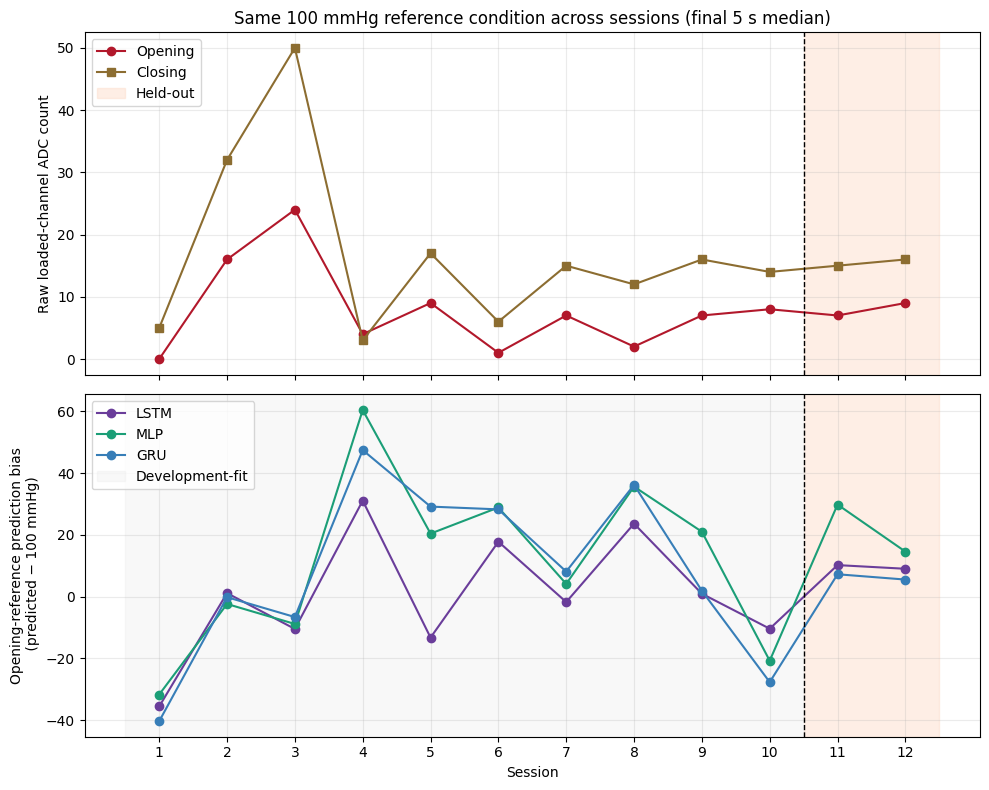

In [45]:
# Examine the repeated reference condition across development and held-out sessions
def drift_analysis(units, all_records, all_true, all_predictions):
    rows = []
    for unit_index, unit in enumerate(units):
        if unit.kind != "reference_hold":
            continue
        loaded = np.flatnonzero(unit.loaded)
        raw = np.median(unit.x[loaded[-125:]], axis=0)
        positions = np.flatnonzero(
            (all_records[:, 0] == unit_index) & (all_true.max(axis=1) > 0))[-6:]
        for label, stack in all_predictions.items():
            prediction = float(
                stack[:, positions, unit.cell].mean())
            rows.append({
                "session": unit.session,
                "session_number": unit.session_number,
                "component": unit.component,
                "model": label,
                "raw_loaded_channel_adc": float(raw[unit.cell]),
                "raw_vector_norm": float(np.linalg.norm(raw)),
                "prediction_mmhg": prediction,
                "residual_mmhg": prediction - 100.0,
                "split": (
                    "development-fit"
                    if unit.session_number <= 10
                    else "held-out"),})
    frame = pd.DataFrame(rows)
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    raw = frame[frame.model == "LSTM"]
    for component, marker, color in [
        ("reference_opening", "o", EDA_COLOURS["opening"]),
        ("reference_closing", "s", EDA_COLOURS["closing"]),]:
        part = raw[raw.component == component]
        axes[0].plot(part.session_number, part.raw_loaded_channel_adc, marker=marker, color=color, label=component.replace("reference_", "").capitalize(),)
    for label in all_predictions:
        part = frame[
            (frame.model == label) & (frame.component == "reference_opening")]
        axes[1].plot(part.session_number, part.residual_mmhg, marker="o", label=label, color=MODEL_COLOURS[label],)
    for axis in axes:
        axis.axvspan(10.5, 12.5, color="#fddbc7", alpha=0.45, label="Held-out" if axis is axes[0] else None,)
        if axis is axes[1]:
            axis.axvspan(0.5, 10.5, color="0.9", alpha=0.25, label="Development-fit",)
        axis.axvline(10.5, color="black", ls="--", lw=1,)
        axis.grid(alpha=0.25)
        axis.legend(loc="upper left")
    axes[0].set_ylabel("Raw loaded-channel ADC count")
    axes[0].set_title("Same 100 mmHg reference condition across sessions (final 5 s median)")
    axes[1].set_ylabel("Opening-reference prediction bias\n (predicted − 100 mmHg)")
    axes[1].set_xlabel("Session")
    axes[1].set_xticks(range(1, 13))
    fig.tight_layout()
    save_figure(fig, FIGURES_DIR, "reference_drift_raw_and_residual.png",)
    frame.to_csv(TABLES_DIR / "reference_drift_across_sessions.csv", index=False,)
    return frame

# Generate all-session predictions before running the drift analysis
all_records, all_true, lstm_all = predict_all_sessions(units, lstm_result,)
all_records_mlp, all_true_mlp, mlp_all = predict_all_sessions(units, mlp_result,)
if not np.array_equal(all_records, all_records_mlp):
    raise ValueError("All-session prediction alignment failed")
all_records_gru, all_true_gru, gru_all = predict_all_sessions(units, gru_result,)
if not np.array_equal(all_records, all_records_gru):
    raise ValueError("GRU all-session prediction alignment failed")
drift_table = drift_analysis(units, all_records, all_true, {"LSTM": lstm_all, "MLP": mlp_all, "GRU": gru_all,},)

# **ADDITIONAL ANALYSES**

,Model,Nominal pressure (mmHg),Mean MAE (mmHg),SD across seeds (mmHg),Units
0,GRU,10.0,20.740,3.171,12
1,GRU,32.0,24.783,2.373,13
2,GRU,50.0,41.522,4.932,12
3,GRU,75.0,46.999,2.602,12
4,GRU,100.0,31.408,5.088,18
5,GRU,150.0,40.277,4.321,12
6,GRU,199.9,47.304,11.336,13
7,GRU,249.9,86.275,5.181,10
8,LSTM,10.0,22.979,7.293,12
9,LSTM,32.0,20.027,2.664,13


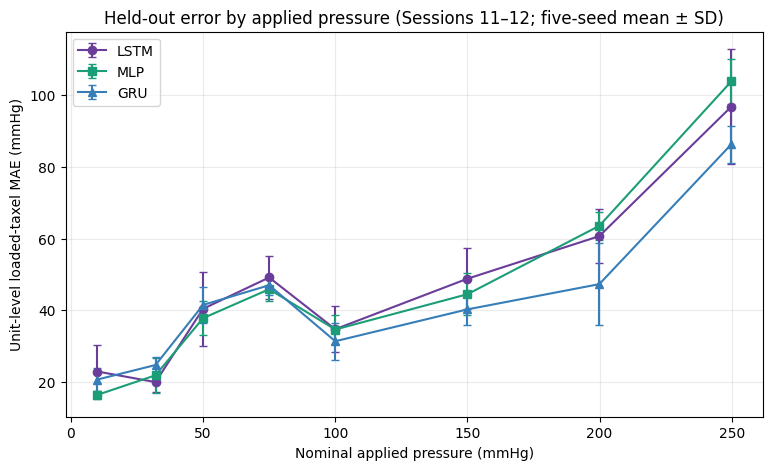

In [46]:
# Quantify held-out calibration error across the nominal pressure ladder
def pressure_error_analysis(units, family_results):
    rows = []
    for label, result in family_results.items():
        records = result["records"]
        y_true = result["y_true"]
        for seed_index, seed in enumerate(FINAL_SEEDS):
            prediction = result["predictions"][seed_index]
            for unit_index in np.unique(records[:, 0]):
                unit = units[int(unit_index)]
                positions = np.flatnonzero(
                    (records[:, 0] == unit_index) & (y_true.max(axis=1) > 0))
                if not len(positions):
                    continue
                error = (
                    prediction[positions, unit.cell] - unit.pressure)
                rows.append({
                    "model": label,
                    "seed": seed,
                    "session": unit.session,
                    "unit_id": unit.unit_id,
                    "pressure_mmhg": unit.pressure,
                    "unit_loaded_mae_mmhg": float(
                        np.abs(error).mean()),})
    frame = pd.DataFrame(rows)
    per_seed = (
        frame
        .groupby(
            ["model", "seed", "pressure_mmhg"],
            as_index=False,
        )["unit_loaded_mae_mmhg"]
        .mean())
    summary = (
        per_seed
        .groupby(["model", "pressure_mmhg"])
        ["unit_loaded_mae_mmhg"]
        .agg(["mean", "std"])
        .reset_index())
    unit_counts = (
        frame[
            ["model", "pressure_mmhg", "session", "unit_id"]]
        .drop_duplicates()
        .groupby(["model", "pressure_mmhg"])
        .size()
        .rename("units")
        .reset_index())
    summary = summary.merge(unit_counts, on=["model", "pressure_mmhg"],)
    display(
        summary.rename(columns={
            "model": "Model",
            "pressure_mmhg": "Nominal pressure (mmHg)",
            "mean": "Mean MAE (mmHg)",
            "std": "SD across seeds (mmHg)",
            "units": "Units",}).round(3))
    summary.to_csv(TABLES_DIR / "heldout_error_by_pressure.csv", index=False,)
    fig, axis = plt.subplots(figsize=(9, 5))
    markers = {"LSTM": "o", "MLP": "s", "GRU": "^",}
    for label in ["LSTM", "MLP", "GRU"]:
        if label not in family_results:
            continue
        part = (
            summary[summary.model == label]
            .sort_values("pressure_mmhg"))
        axis.errorbar(part.pressure_mmhg, part["mean"], yerr=part["std"], marker=markers[label], capsize=3, color=MODEL_COLOURS[label], label=label,)
    axis.set_xlabel("Nominal applied pressure (mmHg)")
    axis.set_ylabel("Unit-level loaded-taxel MAE (mmHg)")
    axis.set_title("Held-out error by applied pressure (Sessions 11–12; five-seed mean ± SD)")
    axis.grid(alpha=0.25)
    axis.legend(loc="upper left")
    save_figure(fig, FIGURES_DIR, "heldout_error_by_pressure.png",)
    return summary

pressure_error_table = pressure_error_analysis(units, family_results,)

,Model,Distance (taxels),Mean false pressure (mmHg),SD across seeds (mmHg),Mean crosstalk (% nominal),SD across seeds (%),Units
0,GRU,1,30.731,1.323,52.385,4.295,102
1,GRU,2,10.878,0.853,23.137,3.015,102
2,GRU,3,8.746,0.856,18.553,3.822,102
3,GRU,4,9.959,1.655,18.186,4.246,102
4,GRU,5,6.175,1.124,12.396,1.749,63
5,GRU,6,7.653,5.399,23.853,8.227,16
6,LSTM,1,20.825,3.063,38.078,6.073,102
7,LSTM,2,9.115,1.023,17.898,2.883,102
8,LSTM,3,6.702,0.984,14.514,2.853,102
9,LSTM,4,6.537,1.070,11.825,1.200,102


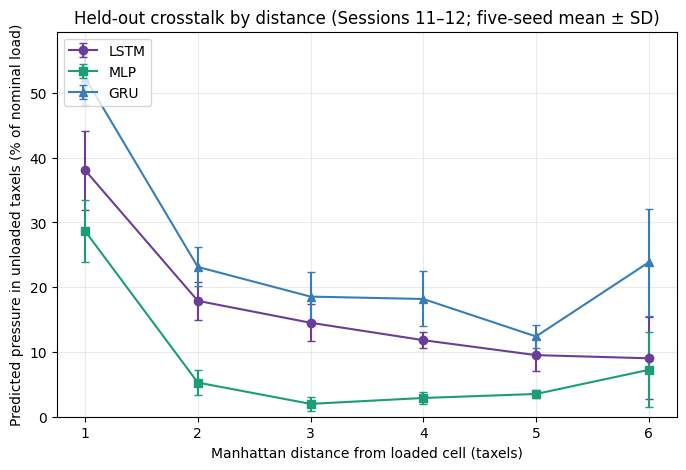

In [47]:
# Quantify residual crosstalk by distance from the loaded taxel
def crosstalk_analysis(units, family_results):
    rows = []
    for label, result in family_results.items():
        records = result["records"]
        y_true = result["y_true"]
        for seed_index, seed in enumerate(FINAL_SEEDS):
            prediction = result["predictions"][seed_index]
            for unit_index in np.unique(records[:, 0]):
                unit = units[int(unit_index)]
                positions = np.flatnonzero(
                    (records[:, 0] == unit_index) & (y_true.max(axis=1) > 0))
                if not len(positions):
                    continue
                values = prediction[positions].mean(axis=0)
                loaded_row, loaded_col = divmod(unit.cell, 4)
                for cell in range(16):
                    if cell == unit.cell:
                        continue
                    row, col = divmod(cell, 4)
                    distance = (abs(row - loaded_row) + abs(col - loaded_col))
                    rows.append({
                        "model": label,
                        "seed": seed,
                        "session": unit.session,
                        "unit_id": unit.unit_id,
                        "distance_manhattan": distance,
                        "false_pressure_mmhg": float(values[cell]),
                        "normalised_false_pressure": float(values[cell] / unit.pressure),})
    frame = pd.DataFrame(rows)
    # Average taxels at the same distance within each acquisition unit
    per_unit = (
        frame
        .groupby(
            ["model", "seed", "session", "unit_id", "distance_manhattan",],
            as_index=False,)
        .agg(
            false_pressure_mmhg=("false_pressure_mmhg", "mean",),
            normalised_false_pressure=("normalised_false_pressure", "mean",),))
    # Average acquisition units within each seed
    per_seed = (
        per_unit
        .groupby(
            ["model", "seed", "distance_manhattan"],
            as_index=False,)
        .agg(
            false_pressure_mmhg=("false_pressure_mmhg", "mean",),
            normalised_false_pressure=("normalised_false_pressure", "mean",),))
    # Summarise variability across the five final seeds
    summary = (
        per_seed
        .groupby(["model", "distance_manhattan"])
        .agg(
            false_pressure_mean_mmhg=("false_pressure_mmhg", "mean",),
            false_pressure_sd_mmhg=("false_pressure_mmhg", "std",),
            normalised_mean=("normalised_false_pressure", "mean",),
            normalised_sd=("normalised_false_pressure","std",),)
        .reset_index())
    unit_counts = (
        per_unit[
            ["model", "session", "unit_id", "distance_manhattan",]]
        .drop_duplicates()
        .groupby(["model", "distance_manhattan"])
        .size()
        .rename("units")
        .reset_index())
    summary = summary.merge( unit_counts, on=["model", "distance_manhattan"],)
    display_table = pd.DataFrame({
        "Model": summary["model"],
        "Distance (taxels)": summary["distance_manhattan"],
        "Mean false pressure (mmHg)":
            summary["false_pressure_mean_mmhg"],
        "SD across seeds (mmHg)":
            summary["false_pressure_sd_mmhg"],
        "Mean crosstalk (% nominal)":
            100 * summary["normalised_mean"],
        "SD across seeds (%)":
            100 * summary["normalised_sd"],
        "Units": summary["units"],})
    display(display_table.round(3))
    summary.to_csv(TABLES_DIR / "crosstalk_by_distance.csv", index=False,)
    fig, axis = plt.subplots(figsize=(8, 5))
    markers = {"LSTM": "o", "MLP": "s", "GRU": "^",}
    for label in ["LSTM", "MLP", "GRU"]:
        if label not in family_results:
            continue
        part = (
            summary[summary.model == label]
            .sort_values("distance_manhattan"))
        axis.errorbar(part.distance_manhattan, 100 * part.normalised_mean, yerr=100 * part.normalised_sd, marker=markers[label], capsize=3, color=MODEL_COLOURS[label], label=label,)
    axis.set_xlabel("Manhattan distance from loaded cell (taxels)")
    axis.set_ylabel("Predicted pressure in unloaded taxels (% of nominal load)")
    axis.set_title("Held-out crosstalk by distance (Sessions 11–12; five-seed mean ± SD)")
    axis.set_ylim(bottom=0)
    axis.grid(alpha=0.25)
    axis.legend(loc="upper left")
    save_figure(fig, FIGURES_DIR, "crosstalk_by_distance.png",)
    return summary

crosstalk_table = crosstalk_analysis(units, family_results,)

,Model,Mean calibrated branch gap (mmHg),SD across seeds (mmHg),Mean calibration MAE (mmHg),MAE SD across seeds (mmHg)
0,GRU,19.823,5.041,28.223,3.234
1,LSTM,18.231,7.528,33.819,7.422
2,MLP,24.651,3.846,34.039,6.360


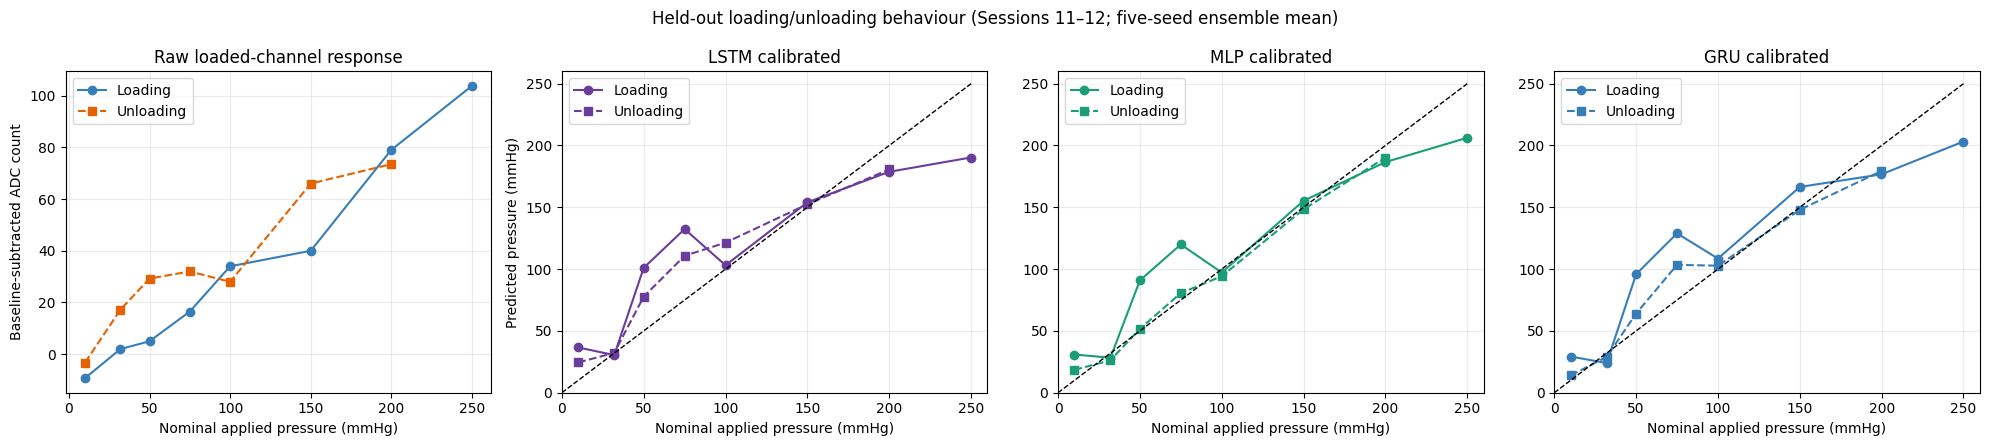

In [48]:
# Compare raw and calibrated loading/unloading behaviour on the test sessions
def hysteresis_analysis(units, family_results):
    # Final 10 s of the loaded hold at 25 Hz
    RAW_LOADED_TAIL_FRAMES = 10 * RATE_HZ
    # Final 2 s of the unloaded baseline at 25 Hz
    RAW_BASELINE_TAIL_FRAMES = 2 * RATE_HZ
    # Approximately the final 10 s of the 1 Hz evaluation records
    EVAL_TAIL_RECORDS = 11

    first_result = next(iter(family_results.values()))
    records = first_result["records"]
    y_true = first_result["y_true"]
    raw_rows = []
    prediction_rows = []
    for unit_index in np.unique(records[:, 0]):
        unit = units[int(unit_index)]
        if unit.kind != "hysteresis_step":
            continue
        direction = hysteresis_direction(unit, units)
        unloaded = np.flatnonzero(~unit.loaded)
        loaded = np.flatnonzero(unit.loaded)
        if not len(unloaded) or not len(loaded):
            continue
        baseline = np.median(
            unit.x[unloaded[-RAW_BASELINE_TAIL_FRAMES:], unit.cell,])
        loaded_response = np.median(
            unit.x[loaded[-RAW_LOADED_TAIL_FRAMES:], unit.cell,])
        raw_response = float(loaded_response - baseline)
        positions = np.flatnonzero(
            (records[:, 0] == unit_index) & (y_true.max(axis=1) > 0))[-EVAL_TAIL_RECORDS:]
        if not len(positions):
            continue
        raw_rows.append({
            "session": unit.session,
            "step": int(unit.hysteresis_step),
            "direction": direction,
            "pressure_mmhg": unit.pressure,
            "baseline_subtracted_adc": raw_response,})
        for label, result in family_results.items():
            for seed_index, seed in enumerate(FINAL_SEEDS):
                prediction = float(
                    result["predictions"][seed_index, positions, unit.cell,].mean())
                prediction_rows.append({
                    "model": label,
                    "seed": seed,
                    "session": unit.session,
                    "step": int(unit.hysteresis_step),
                    "direction": direction,
                    "pressure_mmhg": unit.pressure,
                    "prediction_mmhg": prediction,
                    "signed_error_mmhg": prediction - unit.pressure,})
    raw_frame = pd.DataFrame(raw_rows)
    frame = pd.DataFrame(prediction_rows)
    # Quantify the calibrated loading/unloading branch gap
    loop_rows = []
    for (model, seed, session), part in frame.groupby(
        ["model", "seed", "session"]):
        calibrated = part.pivot_table(
            index="pressure_mmhg",
            columns="direction",
            values="prediction_mmhg",
            aggfunc="mean",).dropna()
        if calibrated.empty:
            continue
        loop_rows.append({
            "model": model,
            "seed": seed,
            "session": session,
            "calibrated_branch_gap_mmhg": float(np.abs(calibrated.loading - calibrated.unloading).mean()),
            "calibration_mae_mmhg": float(np.abs(part.signed_error_mmhg).mean()),})
    loop_summary = pd.DataFrame(loop_rows)
    per_seed = (
        loop_summary
        .groupby(["model", "seed"], as_index=False)
        [["calibrated_branch_gap_mmhg", "calibration_mae_mmhg",]].mean())
    model_summary = (
        per_seed
        .groupby("model")
        .agg(
            branch_gap_mean_mmhg=("calibrated_branch_gap_mmhg", "mean",),
            branch_gap_sd_mmhg=("calibrated_branch_gap_mmhg", "std",),
            mae_mean_mmhg=("calibration_mae_mmhg", "mean",),
            mae_sd_mmhg=("calibration_mae_mmhg", "std",),)
        .reset_index())
    display(
        model_summary.rename(columns={
            "model": "Model",
            "branch_gap_mean_mmhg": "Mean calibrated branch gap (mmHg)",
            "branch_gap_sd_mmhg": "SD across seeds (mmHg)",
            "mae_mean_mmhg": "Mean calibration MAE (mmHg)",
            "mae_sd_mmhg": "MAE SD across seeds (mmHg)",})
        .round(3))
    raw_frame.to_csv(TABLES_DIR / "hysteresis_raw_response.csv", index=False,)
    loop_summary.to_csv(TABLES_DIR / "hysteresis_loop_summary.csv", index=False,)
    model_summary.to_csv(TABLES_DIR / "hysteresis_model_summary.csv", index=False,)
    models = [
        label
        for label in ["LSTM", "MLP", "GRU"]
        if label in family_results]
    fig, axes = plt.subplots(1, 1 + len(models), figsize=(5 * (1 + len(models)), 4.5), squeeze=False,)
    axes = axes.ravel()
    # Average the raw loading and unloading branches across test sessions
    raw_curve = (
        raw_frame
        .groupby(
            ["direction", "pressure_mmhg"],
            as_index=False,)
        ["baseline_subtracted_adc"]
        .mean())
    for direction, marker, linestyle in [("loading", "o", "-"), ("unloading", "s", "--"),]:
        part = raw_curve[ raw_curve.direction == direction]
        axes[0].plot(part.pressure_mmhg, part.baseline_subtracted_adc, marker=marker, linestyle=linestyle, color=EDA_COLOURS[direction], label=direction.capitalize(),)
    axes[0].set_title("Raw loaded-channel response")
    axes[0].set_ylabel("Baseline-subtracted ADC count")
    # Average the calibrated loading and unloading branches across sessions and seeds
    ensemble = (
        frame
        .groupby(
            ["model", "session", "direction", "pressure_mmhg",],
            as_index=False,)
        ["prediction_mmhg"]
        .mean())
    for axis, label in zip(axes[1:], models):
        for direction, marker, linestyle in [("loading", "o", "-"),
            ("unloading", "s", "--"),]:
            part = (
                ensemble[
                    (ensemble.model == label) & (ensemble.direction == direction)]
                .groupby("pressure_mmhg",
                    as_index=False,)
                ["prediction_mmhg"]
                .mean())
            axis.plot(part.pressure_mmhg, part.prediction_mmhg, marker=marker, linestyle=linestyle, color=MODEL_COLOURS[label], label=direction.capitalize(),)
        axis.plot([0, 250], [0, 250], "k--", lw=1,)
        axis.set_title(f"{label} calibrated")
        axis.set_xlim(0, 260)
        axis.set_ylim(0, 260)
    for axis in axes:
        axis.set_xlabel("Nominal applied pressure (mmHg)")
        axis.grid(alpha=0.25)
        axis.legend(loc="upper left")
    if len(axes) > 1:
        axes[1].set_ylabel("Predicted pressure (mmHg)")
    fig.suptitle("Held-out loading/unloading behaviour (Sessions 11–12; five-seed ensemble mean)")
    fig.tight_layout()
    save_figure(fig, FIGURES_DIR, "hysteresis_before_after_calibration.png",)
    return model_summary

hysteresis_table = hysteresis_analysis(units, family_results,)

In [49]:
# Evaluate 32 mmHg threshold detection from each unit's peak predicted taxel pressure
def threshold_detection_analysis(
    units,
    family_results,
    threshold_mmhg=32.0,):
    rows = []
    for label, result in family_results.items():
        records = result["records"]
        y_true = result["y_true"]
        for seed_index, seed in enumerate(FINAL_SEEDS):
            prediction = result["predictions"][seed_index]
            for unit_index in np.unique(records[:, 0]):
                unit = units[int(unit_index)]
                positions = np.flatnonzero(
                    (records[:, 0] == unit_index) & (y_true.max(axis=1) > 0))
                if not len(positions):
                    continue
                unit_prediction = (prediction[positions].mean(axis=0))
                peak_prediction = float(unit_prediction.max())
                rows.append({
                    "model": label,
                    "seed": seed,
                    "session": unit.session,
                    "unit_id": unit.unit_id,
                    "true_pressure_mmhg": unit.pressure,
                    "predicted_peak_mmhg": peak_prediction,
                    "true_positive_class": unit.pressure >= threshold_mmhg,
                    "predicted_positive_class": peak_prediction >= threshold_mmhg,})
    frame = pd.DataFrame(rows)
    metric_rows = []
    for (model, seed), part in frame.groupby(["model", "seed"]):
        true = part.true_positive_class.to_numpy(bool)
        pred = part.predicted_positive_class.to_numpy(bool)
        tp = int(np.sum(true & pred))
        tn = int(np.sum(~true & ~pred))
        fp = int(np.sum(~true & pred))
        fn = int(np.sum(true & ~pred))
        sensitivity = (tp / (tp + fn)
            if (tp + fn)
            else np.nan)
        specificity = (tn / (tn + fp)
            if (tn + fp)
            else np.nan)
        accuracy = ((tp + tn) / len(part)
            if len(part)
            else np.nan)
        balanced_accuracy = ((sensitivity + specificity) / 2
            if np.isfinite(sensitivity)
            and np.isfinite(specificity)
            else np.nan)
        metric_rows.append({
            "model": model,
            "seed": seed,
            "threshold_mmhg": threshold_mmhg,
            "positive_units": tp + fn,
            "negative_units": tn + fp,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "accuracy": accuracy,
            "balanced_accuracy": balanced_accuracy,})
    per_seed = pd.DataFrame(metric_rows)
    summary = (
        per_seed
        .groupby("model")
        .agg(
            positive_units=("positive_units", "first"),
            negative_units=("negative_units", "first"),
            sensitivity_mean=("sensitivity", "mean"),
            sensitivity_sd=("sensitivity", "std"),
            specificity_mean=("specificity", "mean"),
            specificity_sd=("specificity", "std"),
            accuracy_mean=("accuracy", "mean"),
            accuracy_sd=("accuracy", "std"),
            balanced_accuracy_mean=("balanced_accuracy", "mean"),
            balanced_accuracy_sd=("balanced_accuracy", "std"),)
        .reset_index())
    display(
        summary.rename(columns={
            "model": "Model",
            "sensitivity_mean": "Sensitivity mean",
            "sensitivity_sd": "Sensitivity SD",
            "specificity_mean": "Specificity mean",
            "specificity_sd": "Specificity SD",
            "accuracy_mean": "Accuracy mean",
            "accuracy_sd": "Accuracy SD",
            "balanced_accuracy_mean":
                "Balanced accuracy mean",
            "balanced_accuracy_sd":
                "Balanced accuracy SD",
            "positive_units": "Positive units",
            "negative_units": "Negative units",})
        .round(3))
    per_seed.to_csv(TABLES_DIR / "threshold_detection_per_seed.csv", index=False,)
    summary.to_csv(TABLES_DIR / "threshold_detection_summary.csv", index=False,)
    return summary

threshold_table = threshold_detection_analysis(units, family_results, threshold_mmhg=32.0,)

,Model,Positive units,Negative units,Sensitivity mean,Sensitivity SD,Specificity mean,Specificity SD,Accuracy mean,Accuracy SD,Balanced accuracy mean,Balanced accuracy SD
0,GRU,90,12,0.982,0.006,0.167,0.102,0.886,0.016,0.574,0.053
1,LSTM,90,12,0.971,0.013,0.317,0.160,0.894,0.016,0.644,0.077
2,MLP,90,12,0.920,0.014,0.533,0.126,0.875,0.024,0.727,0.067
